# Mac and Linux setup

Use a conda/mamba environment with `modkit 0.6.1` installed (see `README.md`).
If you launch notebooks outside an activated shell, connect the correct kernel (`dimelo-test` by default) so Python, `dimelo`, and `modkit` resolve from the same environment.


# Colab setup

If you are running in Google Colab, run the cells below. **It is expected that Colab will make you restart your runtime to enable new package versions.**
This notebook is pinned to `modkit 0.6.1`.


In [1]:
# Lets Colab access your Google drive
try:
    from google.colab import drive
except:
    print(
        "You don't seem to be running on Google Colab so this cell is not going to be useful for you.\n"
        "Make sure you are running your notebook in a conda environment set up as per README.md.\n"
        "Once you have this notebook running in a correctly configured environment, proceed to the rest of the cells."
    )
else:
    drive.mount('/content/drive')
    # Install condacolab to let us get the modkit dependency
    !pip install -q condacolab
    import condacolab
    condacolab.install()
    # Install pinned modkit version for this notebook
    !conda install -y nanoporetech::modkit==0.6.1
    # Clone the repo, change the active path to be inside the repo, and install the package
    !rm -rf dimelo-toolkit
    !git clone https://github.com/streetslab/dimelo-toolkit
    import os
    os.chdir('dimelo-toolkit')
    !pip install ipywidgets==7.7.1 .


You don't seem to be running on Google Colab so this cell is not going to be useful for you.
Make sure you are running your notebook in a conda environment set up as per README.md.
Once you have this notebook running in a correctly configured environment, proceed to the rest of the cells.


After runtime restart in previous cell, run this cell to make sure your notebook is set up.

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    import os
    os.chdir('dimelo-toolkit')   
except:
    pass

# System and Versions Information

## Conda Environment

Run this cell to list the packages present in your conda environment

In [3]:
!conda activate dimelo-toolkit


CondaError: Run 'conda init' before 'conda activate'



## System Information

Run this cell to list system information about your machine

In [1]:
import platform
print('System:',platform.system())
print('Release:',platform.release())
print('Version:',platform.version())
print('Processor:',platform.processor())


System: Darwin
Release: 25.5.0
Version: Darwin Kernel Version 25.5.0: Thu Apr 23 21:19:59 PDT 2026; root:xnu-12377.121.5~4/RELEASE_ARM64_T6020
Processor: arm


## Git Repo Version

Run this cell to capture the exact repo version you're running, in case we need to debug anything

In [2]:
!git -C . log -1 --format=%H

48d55c3d37523f09a7aead10b19b0afe426f2930


## Modkit Version Requirement (`0.6.1`)

This notebook is intentionally pinned to `modkit 0.6.1`.
It will fail fast if your active `modkit` version does not match, so parsing/extraction behavior is reproducible.


In [3]:
import re
import shutil
import subprocess

# Notebook requirement: keep parsing/extract behavior fixed to 0.6.1.
REQUIRED_MODKIT_VERSION = "0.6.1"
AUTO_INSTALL_REQUIRED_MODKIT = False


def _installed_modkit_version(binary: str = "modkit") -> str | None:
    try:
        proc = subprocess.run([binary, "--version"], capture_output=True, text=True, check=True)
    except Exception:
        return None
    text = (proc.stdout or proc.stderr or "").strip()
    m = re.search(r"(\d+\.\d+\.\d+)", text)
    return m.group(1) if m else text


def ensure_modkit_061(
    required: str = REQUIRED_MODKIT_VERSION,
    binary: str = "modkit",
    auto_install: bool = AUTO_INSTALL_REQUIRED_MODKIT,
) -> str:
    installed = _installed_modkit_version(binary)

    if installed != required and auto_install:
        installer = shutil.which("mamba") or shutil.which("conda")
        if installer is None:
            raise RuntimeError(
                "modkit version mismatch and no conda/mamba installer found on PATH. "
                "Install modkit manually or switch to the intended environment."
            )
        subprocess.run([installer, "install", "-y", f"nanoporetech::modkit=={required}"], check=True)
        installed = _installed_modkit_version(binary)

    # Clear cached capability detection so flags match the active binary.
    try:
        from dimelo import run_modkit

        run_modkit._get_modkit_capabilities_cached.cache_clear()
    except Exception:
        pass

    if installed != required:
        raise RuntimeError(
            f"Notebook requires modkit {required}, but PATH resolves to {installed!r}. "
            "Activate the intended environment, or set AUTO_INSTALL_REQUIRED_MODKIT=True."
        )

    print(f"modkit required: {required}")
    print(f"modkit active  : {installed}")
    return binary


MODKIT_BINARY = ensure_modkit_061()


def run_modkit_checked(args: list[str]) -> None:
    ensure_modkit_061(binary=MODKIT_BINARY)
    cmd = [MODKIT_BINARY, *[str(a) for a in args]]
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True)


modkit required: 0.6.1
modkit active  : 0.6.1


## Modkit Version Comparison (Cached Results)

This cell summarizes the cached benchmark at `modkit_test_results.json` and compares runtime/output behavior across tested versions.


,version,runtime_mean_s,runtime_std_s,runtime_min_s,runtime_max_s
0,0.6.1,2.081953,0.276318,1.766293,2.280039
1,0.2.4,5.246848,0.370882,5.006230,5.673964


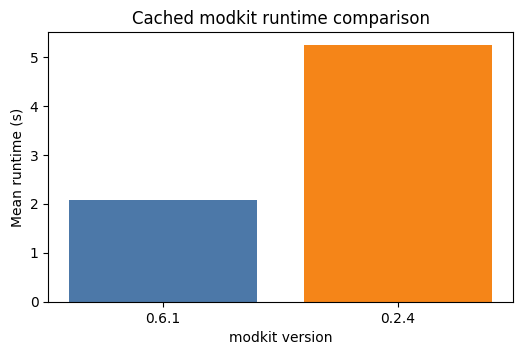

Compatibility flags


,version,supports_force_allow_implicit,supports_modified_bases,supports_reference_long_opt,supports_reference_short_opt
0,0.2.4,True,False,False,True
1,0.6.1,False,True,True,True


Pileup comparison summary


,row_delta,row_delta_pct_vs_024,outputs_identical_sha256
0,1603,0.312757,False


Recommendations
- Prefer modkit 0.6.1 for pileup runtime in this workflow (~60.3% faster on average).
- Backend-aware command building is required: use --force-allow-implicit for 0.2.4 only.

Re-checking required modkit binary after comparison...
modkit required: 0.6.1
modkit active  : 0.6.1


In [4]:
import json
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt

results_path = Path("modkit_test_results.json")
if not results_path.exists():
    print(f"No benchmark file found at {results_path}.")
    print("This notebook still requires modkit 0.6.1 even without cached comparison results.")
else:
    results = json.loads(results_path.read_text())

    runtime_summary = pd.DataFrame(results.get("runtime_summary", []))
    if not runtime_summary.empty:
        runtime_summary = runtime_summary.sort_values("runtime_mean_s").reset_index(drop=True)
        display(runtime_summary)

        fig, ax = plt.subplots(figsize=(6, 3.5))
        ax.bar(runtime_summary["version"], runtime_summary["runtime_mean_s"], color=["#4C78A8", "#F58518", "#54A24B"])
        ax.set_ylabel("Mean runtime (s)")
        ax.set_xlabel("modkit version")
        ax.set_title("Cached modkit runtime comparison")
        plt.show()

        best_version = str(runtime_summary.iloc[0]["version"])
        if best_version != REQUIRED_MODKIT_VERSION:
            print(
                f"WARNING: cached benchmark fastest version is {best_version}, "
                f"but notebook remains pinned to {REQUIRED_MODKIT_VERSION} for reproducibility."
            )

    edge_flags = pd.DataFrame(results.get("edge_case_flags", []))
    if not edge_flags.empty:
        print("Compatibility flags")
        display(edge_flags)

    pileup_cmp = results.get("pileup_comparison", {})
    if pileup_cmp:
        print("Pileup comparison summary")
        display(pd.DataFrame([pileup_cmp]))

    print("Recommendations")
    for rec in results.get("recommendations", []):
        print(f"- {rec}")

print("\nRe-checking required modkit binary after comparison...")
MODKIT_BINARY = ensure_modkit_061(binary=MODKIT_BINARY, auto_install=False)


# Initialization

In [5]:
from pathlib import Path
from matplotlib import pyplot as plt    
import urllib, gzip

In [6]:
# Ensure this notebook imports the local repo version of dimelo
import importlib
from pathlib import Path
import dimelo

importlib.reload(dimelo)
print('dimelo module path:', Path(dimelo.__file__).resolve())
print('dimelo version:', getattr(dimelo, '__version__', 'unknown'))


dimelo module path: /Users/ngamarra/Documents/GitHub/dimelo-toolkit/dimelo/__init__.py
dimelo version: unknown


In [7]:
# Base input and output directories
test_data_dir = Path('./dimelo/test/data')
output_dir = Path('./dimelo/test/output')

output_dir.mkdir(exist_ok=True)

# Input files
ctcf_bam_file = test_data_dir / 'ctcf_demo.sorted.bam'
ctcf_guppy_bam_file = test_data_dir / 'winnowmap_guppy_merge_subset.updated.bam'
ctcf_target_regions = test_data_dir / 'ctcf_demo_peak.bed'
ctcf_off_target_regions = test_data_dir / 'ctcf_demo_not_peak.bed'

The cell below only needs to run once; if you try to run it with the reference genome already downloaded it will likely just not complete.

In [8]:
ref_genome_url = 'https://s3-us-west-2.amazonaws.com/human-pangenomics/T2T/CHM13/assemblies/chm13.draft_v1.0.fasta.gz'
ref_genome_gz = output_dir / 'chm13.draft_v1.0.fasta.gz'
ref_genome_file = output_dir / 'chm13.draft_v1.0.fasta'
force_redownload = False
if ref_genome_file.exists() and not force_redownload:
    print('Reference genome already present. Set force_redownload=True to if you want to download it again.')
else:
    urllib.request.urlretrieve(ref_genome_url,ref_genome_gz)

    with gzip.open(ref_genome_gz,'rb') as gzip_file:
        with open(ref_genome_file,'wb') as output_file:
            for chunk in gzip_file:
                output_file.write(chunk)

    ref_genome_gz.unlink()
    print("Reference genome downloaded and decompressed.")
# !curl https://s3-us-west-2.amazonaws.com/human-pangenomics/T2T/CHM13/assemblies/chm13.draft_v1.0.fasta.gz -o ./test/output/chm13.draft_v1.0.fasta.gz
# !gunzip ./test/output/chm13.draft_v1.0.fasta.gz

Reference genome already present. Set force_redownload=True to if you want to download it again.


In [13]:
import importlib
import gzip
from pathlib import Path
from dimelo import parse_bam, run_modkit

# Ensure notebook uses latest local backend code and capability logic.
importlib.reload(run_modkit)
importlib.reload(parse_bam)

# Reset cached capability detection after reloads/version changes.
run_modkit._get_modkit_capabilities_cached.cache_clear()

# Notebook-safe default: suppress live tqdm progress from parse/extract in Jupyter.
# This avoids mangled carriage-return output while preserving deterministic results.
PARSE_QUIET = False

# Output overwrite policy for parse cells below.
# False: reuse existing complete outputs under output_name.
# True: force regeneration and replace existing outputs.
PARSE_OVERWRITE = True

print(f"PARSING quiet mode for notebook progress: {PARSE_QUIET}")
print(f"PARSING overwrite mode: {PARSE_OVERWRITE}")


def _has_any_bed_rows(bgzip_bed: Path) -> bool:
    if not bgzip_bed.exists() or bgzip_bed.stat().st_size < 80:
        return False
    try:
        with gzip.open(bgzip_bed, "rt") as f:
            next(f)
        return True
    except Exception:
        return False


def _has_any_extract_rows(extract_h5: Path) -> bool:
    if not extract_h5.exists() or extract_h5.stat().st_size < 1024:
        return False
    try:
        import h5py

        with h5py.File(extract_h5, "r") as h5:
            return "read_name" in h5 and len(h5["read_name"]) > 0
    except Exception:
        return False


def ensure_pileup_output(*, output_name: str, overwrite: bool | None = None, **pileup_kwargs):
    if overwrite is None:
        overwrite = PARSE_OVERWRITE
    out_dir = Path(pileup_kwargs["output_directory"])
    pileup_out = out_dir / output_name / "pileup.sorted.bed.gz"
    regions_out = out_dir / output_name / "regions.processed.bed"

    existing_complete = (
        pileup_out.exists()
        and Path(str(pileup_out) + ".tbi").exists()
        and regions_out.exists()
        and _has_any_bed_rows(pileup_out)
    )

    if (not overwrite) and existing_complete:
        print(f"Reusing existing pileup outputs: {pileup_out}")
        return pileup_out, regions_out

    if (not overwrite) and pileup_out.exists() and not _has_any_bed_rows(pileup_out):
        print(f"Detected empty/invalid pileup output at {pileup_out}; regenerating.")
        overwrite = True

    return parse_bam.pileup(output_name=output_name, overwrite=overwrite, **pileup_kwargs)


def ensure_extract_output(*, output_name: str, overwrite: bool | None = None, **extract_kwargs):
    if overwrite is None:
        overwrite = PARSE_OVERWRITE
    out_dir = Path(extract_kwargs["output_directory"])
    extract_out = out_dir / output_name / "reads.combined_basemods.h5"
    regions_out = out_dir / output_name / "regions.processed.bed"

    existing_complete = (
        extract_out.exists()
        and regions_out.exists()
        and _has_any_extract_rows(extract_out)
    )

    if (not overwrite) and existing_complete:
        print(f"Reusing existing extract outputs: {extract_out}")
        return extract_out, regions_out

    if (not overwrite) and extract_out.exists() and not _has_any_extract_rows(extract_out):
        print(f"Detected empty/invalid extract output at {extract_out}; regenerating.")
        overwrite = True

    return parse_bam.extract(output_name=output_name, overwrite=overwrite, **extract_kwargs)


PARSING quiet mode for notebook progress: False
PARSING overwrite mode: True


# Basic Use Overview

For details on parameters and functionality breakdown, please read the README sections on **Basic Use**, especially **Parameters and what they mean**.

# Parsing

## Pileup and Update Tags

Attempting to parse a malformed BAM file will raise an error, thanks to input BAM format checking. Passing a bam file that doesn't meet the specifications directly to `modkit` will typically result in an empty ouput file; `modkit` will find no valid base modifications and return all-zero data.

Megalodon and Guppy bam files are considered malformed because they do not meet the latest .bam spec. Some newer basecallers output correctly formatted files without requiring additional processing.

However, `modkit` comes with two tools that can update bam files to meet spec.

In [13]:
try:
    pileup_file, pileup_regions = parse_bam.pileup(
        input_file=ctcf_bam_file,
        output_name='ctcf_demo_pileup_on_target',
        ref_genome=ref_genome_file,
        output_directory=output_dir,
        regions=[ctcf_target_regions,ctcf_off_target_regions],
        motifs=['A,0','CG,0'],
        # parsing can optionally specify mod codes. 
        # The default is Y or a for adenine and m or Z for cytosine, corresponding to methylation
        # motifs = ['A,0,Y','CG,0,Z'], 
        thresh=128,
        window_size=1000,
        # cores = 1, # uncomment this line if your process appears to be terminating early (reduces memory usage)
        # quiet = True,
        # cleanup = False,
        # log=True,
        quiet=PARSE_QUIET,
        modkit_executable=MODKIT_BINARY,
    )
    print('The code executed successfully.')
except Exception as e:
    print('This is expected to fail. Read the error message below:\n\n')
    print(e)


This is expected to fail. Read the error message below:


Base modification tags are out of spec (Mm and Ml instead of MM and ML). 

Consider using "modkit update-tags dimelo/test/data/ctcf_demo.sorted.bam new_file.bam" in the command line with your conda environment active and then trying with the new file. For megalodon basecalling/modcalling, you may also need to pass "--mode ambiguous.
Be sure to index the resulting .bam file."
If you are confident that your inputs are ok, pass "override_checks=True" to convert to warning and proceed with processing.


To fix this, follow the suggestion from the error and run `modkit update-tags`...

In [9]:
import shutil
from pathlib import Path

import pysam

ctcf_bam_file_updated = output_dir / "ctcf_demo.updated.bam"
ctcf_bam_file_updated_tmp = output_dir / "ctcf_demo.updated.tmp.bam"

# Always regenerate this file for deterministic notebook reruns.
for stale in [
    ctcf_bam_file_updated,
    Path(str(ctcf_bam_file_updated) + ".bai"),
    ctcf_bam_file_updated_tmp,
    Path(str(ctcf_bam_file_updated_tmp) + ".bai"),
]:
    stale.unlink(missing_ok=True)

run_modkit_checked([
    "update-tags",
    str(ctcf_bam_file),
    str(ctcf_bam_file_updated_tmp),
    "--mode",
    "ambiguous",
])

# Quick sanity check before promoting the file into the main path.
pysam.quickcheck(str(ctcf_bam_file_updated_tmp))
shutil.move(str(ctcf_bam_file_updated_tmp), str(ctcf_bam_file_updated))
Path(str(ctcf_bam_file_updated_tmp) + ".bai").unlink(missing_ok=True)

print(f"Updated BAM ready: {ctcf_bam_file_updated}")


modkit required: 0.6.1
modkit active  : 0.6.1
$ modkit update-tags dimelo/test/data/ctcf_demo.sorted.bam dimelo/test/output/ctcf_demo.updated.tmp.bam --mode ambiguous
Updated BAM ready: dimelo/test/output/ctcf_demo.updated.bam


> done, 1024 records processed


In [10]:
print(f'Using updated BAM: {ctcf_bam_file_updated}')

Using updated BAM: dimelo/test/output/ctcf_demo.updated.bam


...and reindex the resulting file.

In [11]:
import pysam
from pathlib import Path

index_path = Path(str(ctcf_bam_file_updated) + ".bai")
index_path.unlink(missing_ok=True)

# Rebuild the BAM index from scratch for deterministic reruns.
pysam.index(str(ctcf_bam_file_updated))
print(f"Indexed {ctcf_bam_file_updated} -> {index_path}")


Indexed dimelo/test/output/ctcf_demo.updated.bam -> dimelo/test/output/ctcf_demo.updated.bam.bai


Finally, the updated .bam file can be parsed, both for pileup and read extraction:

In [14]:
pileup_file, pileup_regions = ensure_pileup_output(
    input_file=ctcf_bam_file_updated,
    output_name='ctcf_demo_pileup_on_target',
    ref_genome=ref_genome_file,
    output_directory=output_dir,
    regions=[ctcf_target_regions,ctcf_off_target_regions],
    motifs=['A,0','CG,0'],
    # parsing can optionally specify mod codes.
    # The default is Y or a for adenine and m or Z for cytosine, corresponding to methylation
    # motifs=['A,0,Y','CG,0,Z'],
    thresh=190,
    window_size=1000,
    # cores=1,  # uncomment to reduce memory usage
    # cleanup=False,
    # log=True,
    quiet=PARSE_QUIET,
    modkit_executable=MODKIT_BINARY,
)


No specified number of cores requested. 10 available on machine, allocating all.
Detected multiple motif contexts with modkit 0.6.x; running per-motif pileups and merging outputs to avoid mixed-motif empty output behavior.
Modification threshold of 190.0 assumed to be for range 0-255. 190.0/255=0.7450980392156863 will be sent to modkit.


KeyboardInterrupt: 

In [18]:
import gzip
with gzip.open(pileup_file, "rt") as f:
    n = sum(1 for _ in f)
print("pileup rows:", n)


pileup rows: 246104


## Extract

In [15]:
extract_file, extract_regions = ensure_extract_output(
    input_file=ctcf_bam_file_updated,
    output_name='ctcf_demo_extract',
    ref_genome=ref_genome_file,
    output_directory=output_dir,
    regions=[ctcf_target_regions,ctcf_off_target_regions],
    motifs=['A,0','CG,0'],
    # parsing can optionally specify mod codes.
    # The default is Y or a for adenine and m or Z for cytosine, corresponding to methylation
    # motifs=['A,0,Y','CG,0,Z'],
    thresh=190,
    window_size=2000,
    # cores=1,  # uncomment to reduce memory usage
    # cleanup=False,
    # log=True,
    quiet=PARSE_QUIET,
    modkit_executable=MODKIT_BINARY,
)


No specified number of cores requested. 10 available on machine, allocating all.
Modification threshold of 190.0 assumed to be for range 0-255. 190.0/255=0.7450980392156863 will be sent to modkit.
Threshold provided. The extract text will stay probability-valued and read_by_base_txt_to_hdf5 will binarize at write time.


# Plotting

## Plot Enrichment Profile

In [20]:
from dimelo import plot_enrichment_profile

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

<Axes: xlabel='pos', ylabel='fraction modified bases'>

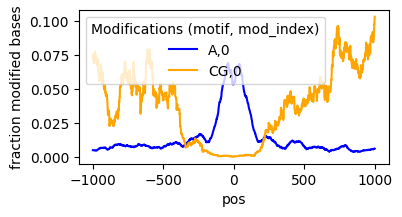

In [21]:
plt.figure(figsize=(4, 2)) # If you want a different sized plot, you can us matplotlib commands
plot_enrichment_profile.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0','CG,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=50,
    palette = { # you can pass down kwargs to sns barplot if you want to
        'A,0':'blue',
        'CG,0':'orange'
    }
)

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/100 [00:00<?, ?it/s]

Text(0, 0.5, 'mA/A')

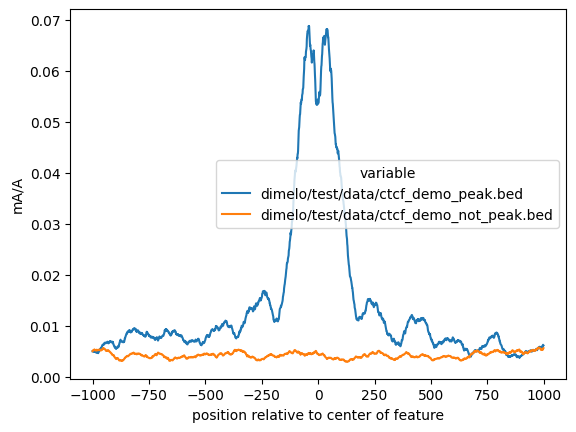

In [22]:
plot_enrichment_profile.by_regions(
    mod_file_name=pileup_file,
    regions_list=[ctcf_target_regions,ctcf_off_target_regions],
    window_size=1000,
    motif='A,0',
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=50,
)
plt.xlabel('position relative to center of feature')
plt.ylabel('mA/A') # You can also use matplotlib commands to rename axes and more

## Plot Enrichment

In [23]:
from dimelo import plot_enrichment

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/100 [00:00<?, ?it/s]

<Axes: ylabel='fraction modified bases'>

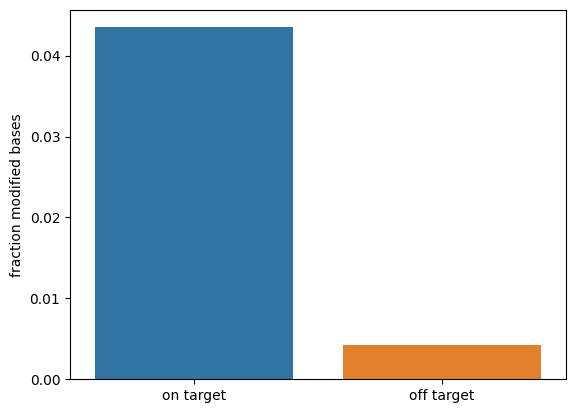

In [24]:
plot_enrichment.by_regions(
    mod_file_name=pileup_file,
    regions_list=[ctcf_target_regions, ctcf_off_target_regions],
    motif='A,0',
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    sample_names=['on target', 'off target'],
    )

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Text(0.5, 1.0, 'dimelo/test/data/ctcf_demo_peak.bed')

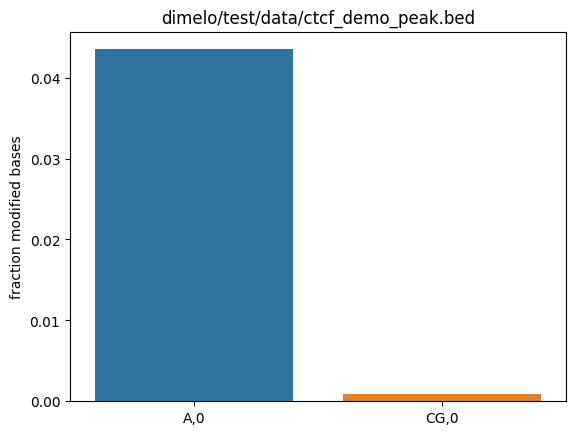

In [25]:
plot_enrichment.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    motifs=['A,0','CG,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    )
plt.title(ctcf_target_regions)

Loading data:   0%|          | 0/100 [00:00<?, ?it/s]

Loading data:   0%|          | 0/100 [00:00<?, ?it/s]

Text(0.5, 1.0, 'dimelo/test/data/ctcf_demo_not_peak.bed')

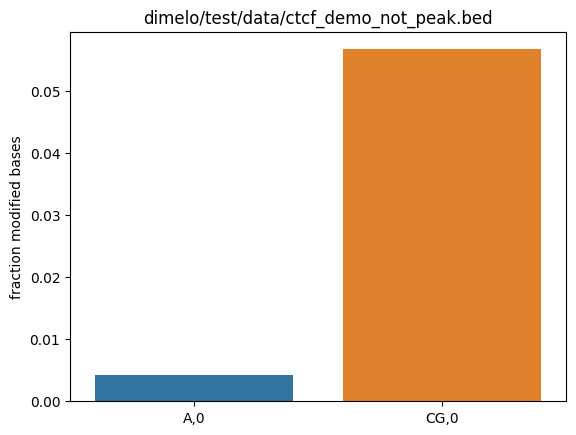

In [26]:
plot_enrichment.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_off_target_regions,
    motifs=['A,0','CG,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    )
plt.title(ctcf_off_target_regions)

## Plot Reads

In [27]:
from dimelo import plot_reads

Text(0.5, 1.0, "CTCF target data, 100 known binding locations\nsort_by=['shuffle'] i.e. default")

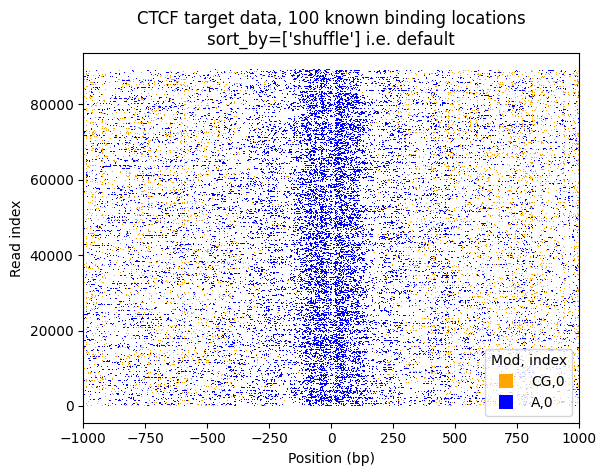

In [28]:
plot_reads.plot_reads(
    mod_file_name=extract_file,
    regions=ctcf_target_regions,
    motifs=['A,0', 'CG,0'],
    window_size=1000,
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
)
plt.title("CTCF target data, 100 known binding locations\nsort_by=['shuffle'] i.e. default")

## Plot Browser

The read browser plot lets you see modification locations and probabilities in the same visualization. While the `pileup` operation and downstream plots by definition requires a threshold, but plot browser requires raw probabilities. Read extraction can be run with *either* binary modification calls *or* raw probabilities. Run the cell below to re-extract the single reads but with raw base modification probabilities for plot browser.

In [29]:
from dimelo import plot_read_browser

In [30]:
try:
    plot_read_browser.plot_read_browser(
    mod_file_name=extract_file,
    region='chr1:114357437-114359753', # you can only browser a single region, not a bed file or list of regions.
    # The only cap on region size is your computer's memory and your patience
    motifs=['CG,0','A,0'],
    thresh=190,
    single_strand=False,
    sort_by="collapse",#you can sort by anything that the loading function accepts, but the special "collapse" option doesn't allow other sorting
    hover=False, #turning off hover will remove the hoverover read names and other info 
    )
except Exception as e:
    print('This is expected to fail. Read the error message below:\n\n')
    print(e)

This is expected to fail. Read the error message below:


A threshold has been applied to this .h5 single read data. plot_read_browser must be used with an .h5 file extracted using thresh=None.


In [31]:
extract_file_no_thresh, _ = ensure_extract_output(
    input_file=ctcf_bam_file_updated,
    output_name='ctcf_demo_extract_no_thresh',
    ref_genome=ref_genome_file,
    output_directory=output_dir,
    regions=[ctcf_target_regions,ctcf_off_target_regions],
    motifs=['A,0','CG,0'],
    # thresh=None -> raw probabilities in read vectors
    window_size=1000,
    # cores=1,  # uncomment to reduce memory usage
    # cleanup=False,
    # log=True,
    quiet=PARSE_QUIET,
    modkit_executable=MODKIT_BINARY,
)


No specified number of cores requested. 10 available on machine, allocating all.
No valid base modification threshold provided. Raw probabilities will be saved.


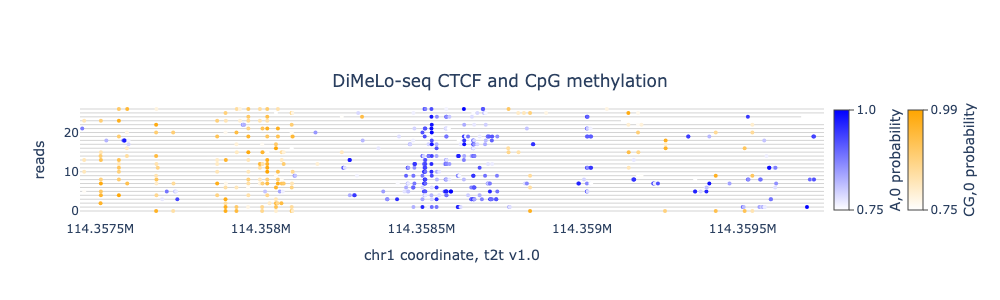

In [32]:
from IPython.display import Image, display
from plotly.io import to_image
fig = plot_read_browser.plot_read_browser(
    mod_file_name=extract_file_no_thresh,
    region='chr1:114357437-114359753', # you can only browser a single region, not a bed file or list of regions.
    # The only cap on region size is your computer's memory and your patience
    motifs=['CG,0','A,0'],
    thresh=190,
    single_strand=False,
    sort_by="collapse",#you can sort by anything that the loading function accepts, but the special "collapse" option doesn't allow other sorting
    hover=False, #turning off hover will remove the hoverover read names and other info
)
# plot browser is made using plotly, so you can use the returned "fig" object to make updates using plotly commands
fig.update_layout(
    width=1000,# these values are in pixels
    height=300,    
    title={
        'text': 'DiMeLo-seq CTCF and CpG methylation',
        'x': 0.5,
        'xanchor': 'center',
        'y': 0.75,  # Adjust the vertical position of the title
        'yanchor': 'top',
        'pad': {'b': 10} 
    },
    xaxis_title='chr1 coordinate, t2t v1.0',
    yaxis_title='reads'
)
# Comment out these lines to display an interactive plot with e.g. zoom and pan
png_bytes = to_image(fig, format="png", width=1000, height=300)
display(Image(png_bytes))

When using the read browser, one can optionally request plotting of a random subset of the reads using the `subset_parameters` argument:

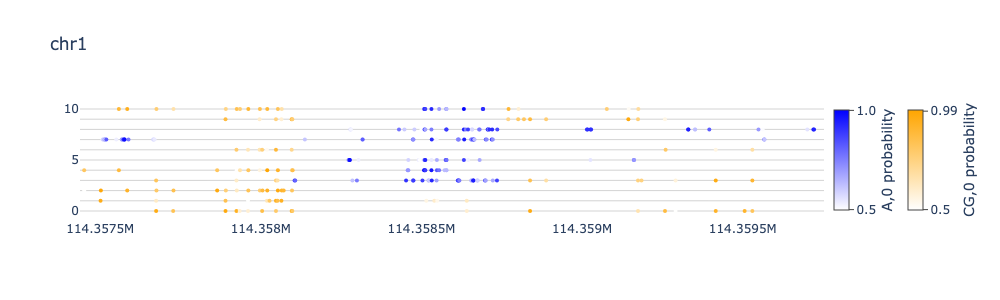

In [33]:
fig = plot_read_browser.plot_read_browser(
    mod_file_name=extract_file_no_thresh,
    region='chr1:114357437-114359753',
    motifs=['CG,0','A,0'],
    thresh=0.5,
    single_strand=False,
    sort_by="collapse",
    hover=False,
    subset_parameters={"frac": 0.25}
)
# Comment out these lines to display an interactive plot with e.g. zoom and pan
png_bytes = to_image(fig, format="png", width=1000, height=300)
display(Image(png_bytes))

## Plot read depth profile

The depth profile plotters allow you to visualize the depth of your data, both at a single locus and across many loci. This is always showing the read depth that is *usable for DiMeLo-seq*, that is to say read depth for the motifs in question where there is mod tag information available for the putatively modified nucleotide. Because not all motifs are reverse-complement-symmetrical, the depth is expressed on a per strand basis. You can use the same single_strand command as in enrichment plotters to only pull data from the strand specified for a region. Otherwise, data will be pulled from both strands, but the populated read depth will for each position only come from one strand, so you will still only get effectively (full read depth) / 2. 

In [34]:
from dimelo import plot_depth_profile

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

<Axes: title={'center': 'Reverse strand mod read depth'}, xlabel='Position (bp)', ylabel='per strand reads\nwith motif and mod info'>

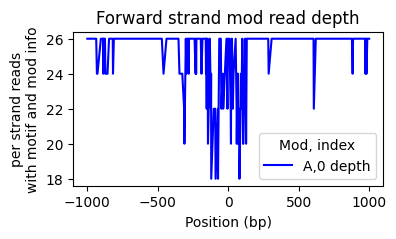

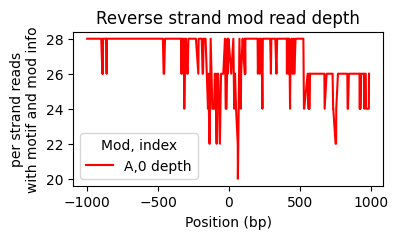

In [35]:
plt.figure(figsize=(4, 2)) # If you want a different sized plot, you can us matplotlib commands
plt.title("Forward strand mod read depth")
plot_depth_profile.by_modification(
    mod_file_name=pileup_file,
    regions='chr1:114357437-114359753,+',
    window_size=1000,
    motifs=['A,0'],
    single_strand=True, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=None,
    palette = { # you can pass down kwargs to sns barplot if you want to
        'A,0 depth':'blue',
    }
)
plt.figure(figsize=(4, 2)) # If you want a different sized plot, you can us matplotlib commands
plt.title("Reverse strand mod read depth")
plot_depth_profile.by_modification(
    mod_file_name=pileup_file,
    regions='chr1:114357437-114359753,-',
    window_size=1000,
    motifs=['A,0'],
    single_strand=True, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=None,
    palette = { # you can pass down kwargs to sns barplot if you want to
        'A,0 depth':'red',
    }
)

You can superimpose plots of mod fraction enrichment and read depth to get a better picture of what is going on, and how meaningful results are. For example, in the below plot, we see that adenines are somewhat depleted at CTCF sites, while CpG motifs are enriched. The adenine modification signal has much higher read depth because `A,0` motifs are much more prevalent than `CG,0` motifs. With this set of loci and read depth, the CpG signal flanking the CTCF sites is quite low depth - explaining the noisy trace.

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

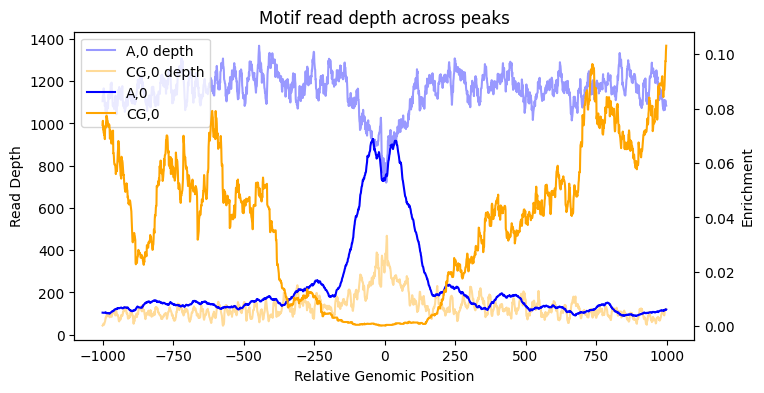

In [36]:
fig, ax1 = plt.subplots(figsize=(8, 4))  # Create figure and primary axis
ax2 = ax1.twinx()  # Create secondary y-axis sharing the same x-axis
plt.title("Motif read depth across peaks")
plot_depth_profile.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0','CG,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=10,
    palette = { # you can pass down kwargs to sns barplot if you want to
        'A,0 depth':'blue',
        'CG,0 depth':'orange',
    },
    alpha=0.4,
    ax=ax1,
)
plot_enrichment_profile.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0','CG,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=50,
    palette = { # you can pass down kwargs to sns barplot if you want to
        'A,0':'blue',
        'CG,0':'orange'
    },
    ax=ax2,
)
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_ylabel("Read Depth")
ax2.set_ylabel("Enrichment")
ax1.set_xlabel("Relative Genomic Position")
ax2.get_legend().remove()

### Plot depth histogram

Depth histograms show the distribution of read depths across sites, either averaging each locus into a single value or providing readouts across all genomic coordinates.

In [37]:
from dimelo import plot_depth_histogram

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

<Axes: xlabel='per strand read\ndepth in region', ylabel='regions count'>

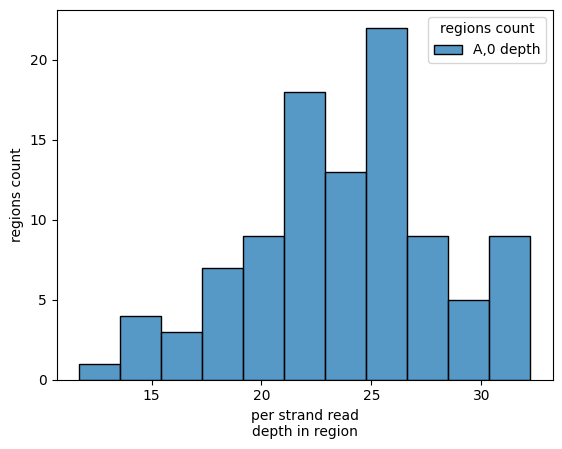

In [38]:
plot_depth_histogram.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0'],#,'CG,0'],
    one_depth_per_region=True,
)

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

<Axes: xlabel='per strand read\ndepth per position', ylabel='positions count'>

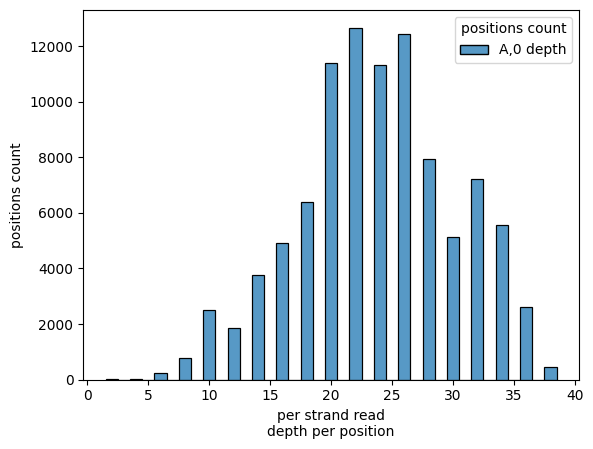

In [39]:
plot_depth_histogram.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0'],#,'CG,0'],
    one_depth_per_region=False,
)

## Export

For some use cases, such as loading pileup information into a genome browser, it can be desireable to create files with less information content than the full bedmethyls. The `export` module contains functions to do these sorts of exports. 

In [40]:
from pathlib import Path

pileup_file = Path(pileup_file)
ref_genome_file = Path(ref_genome_file)

if not pileup_file.exists():
    raise FileNotFoundError(
        f"Expected pileup file not found: {pileup_file}. Run parsing cells above first."
    )

bigwig_out_no_ref = pileup_file.parent / 'pileup.fractions.no_ref.bigwig'
bigwig_out_with_ref = pileup_file.parent / 'pileup.fractions.with_ref.bigwig'

for p in [bigwig_out_no_ref, bigwig_out_with_ref]:
    p.unlink(missing_ok=True)

print('pileup_file:', pileup_file)
print('ref_genome_file:', ref_genome_file)
print('bigwig_out_no_ref:', bigwig_out_no_ref)
print('bigwig_out_with_ref:', bigwig_out_with_ref)


pileup_file: dimelo/test/output/ctcf_demo_pileup_on_target/pileup.sorted.bed.gz
ref_genome_file: dimelo/test/output/chm13.draft_v1.0.fasta
bigwig_out_no_ref: dimelo/test/output/ctcf_demo_pileup_on_target/pileup.fractions.no_ref.bigwig
bigwig_out_with_ref: dimelo/test/output/ctcf_demo_pileup_on_target/pileup.fractions.with_ref.bigwig


In [41]:
from dimelo import export

export.pileup_to_bigwig(
    bedmethyl_file=pileup_file,
    motif='A,0',  # file contains mod fraction for this motif
    bigwig_file=bigwig_out_no_ref,
    strand='.',
    chunk_size=1000,
)
print(f"Wrote {bigwig_out_no_ref}")


Step 1: Indexing contigs in pileup.sorted.bed.gz to set up bigwig header for pileup.fractions.no_ref.bigwig:  …

Indexing chr1.: 0it [00:00, ?it/s]

Indexing chr12.: 0it [00:00, ?it/s]

Indexing chr14.: 0it [00:00, ?it/s]

Indexing chr15.: 0it [00:00, ?it/s]

...

Writing chr7.:   0%|          | 0/6310 [00:00<?, ?it/s]

Writing chr8.:   0%|          | 0/5526 [00:00<?, ?it/s]

Writing chr9.:   0%|          | 0/6464 [00:00<?, ?it/s]

Writing chrX.:   0%|          | 0/13610 [00:00<?, ?it/s]

Wrote dimelo/test/output/ctcf_demo_pileup_on_target/pileup.fractions.no_ref.bigwig


You can specify a ref genome when exporting to bigwig to speed up the setup for the bigwig header that defined contig lengths.

In [42]:
export.pileup_to_bigwig(
    bedmethyl_file=pileup_file,
    motif='A,0',
    bigwig_file=bigwig_out_with_ref,
    ref_genome=ref_genome_file,
    strand='.',
    chunk_size=1000,
)
print(f"Wrote {bigwig_out_with_ref}")


Step 1: Indexing contigs in chm13.draft_v1.0.fasta to set up bigwig header for pileup.fractions.with_ref.bigwi…

Step 2: Writing pileup.sorted.bed.gz contents to pileup.fractions.with_ref.bigwig:   0%|          | 0/17 [00:0…

Writing chr1.: 0it [00:00, ?it/s]

Writing chr12.: 0it [00:00, ?it/s]

Writing chr14.: 0it [00:00, ?it/s]

...

Writing chr7.: 0it [00:00, ?it/s]

Writing chr8.: 0it [00:00, ?it/s]

Writing chr9.: 0it [00:00, ?it/s]

Writing chrX.: 0it [00:00, ?it/s]

Wrote dimelo/test/output/ctcf_demo_pileup_on_target/pileup.fractions.with_ref.bigwig


## Handling single read probabilities with plot_reads

You can still plot .h5 single read files with our `plot_reads` module, but because no threshold was applied in parsing a threshold must be provided to the plotting module.

In [43]:
try:
    plot_reads.plot_reads(
        mod_file_name=extract_file_no_thresh, # the no threshold file
        regions=ctcf_target_regions, # same regions as before
        motifs=['A,0', 'CG,0'],
        window_size=1000,
    )
except Exception as e:
    print('This is expected to fail. Read the error message below:\n\n')
    print(e)

This is expected to fail. Read the error message below:


No threshold has been applied to this .h5 single read data. You must provide a threshold using the thresh parameter in order to extract binarized modification arrays.


Text(0, 0.5, 'reads')

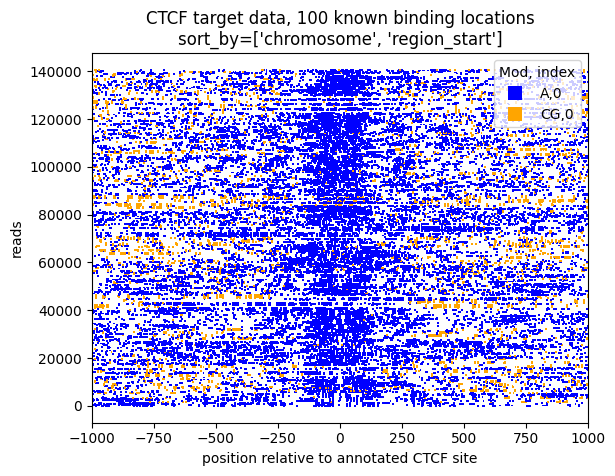

In [44]:
sort_by = ['chromosome','region_start'] # you can sort reads also!
plot_reads.plot_reads(
    mod_file_name=extract_file_no_thresh,
    regions=ctcf_target_regions,
    motifs=['A,0', 'CG,0'],
    window_size=1000,
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=True, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    thresh=128,
    sort_by=sort_by,
    s=2, 
)
plt.title(f'CTCF target data, 100 known binding locations\nsort_by={sort_by}')
plt.xlabel('position relative to annotated CTCF site')
plt.ylabel('reads')

## Manually Loading Processed Data

### Load sum total modified/valid base read counts by genomic regions

In [45]:
from dimelo import load_processed

In [46]:
modified_base_count,valid_base_count = load_processed.pileup_counts_from_bedmethyl(
    bedmethyl_file = pileup_file,
    motif = 'A,0',
    regions = ctcf_target_regions,
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
)
print('total methylated adenines across regions in bed file:',modified_base_count,'\ntotal adenine reads called as methylated or unmethylated across regions in bed file:',valid_base_count)

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

total methylated adenines across regions in bed file: 14242 
total adenine reads called as methylated or unmethylated across regions in bed file: 327326


In [47]:
modified_base_count,valid_base_count = load_processed.pileup_counts_from_bedmethyl(
    bedmethyl_file = pileup_file,
    motif = 'A,0',
    regions = 'chr1:114358436-114358754',
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
)
print('total methylated adenines in single window:',modified_base_count,'\ntotal adenine reads called as methylated or unmethylated in single window:',valid_base_count)

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

total methylated adenines in single window: 213 
total adenine reads called as methylated or unmethylated in single window: 2986


### Load pileup vectors (modified and valid base read counts) aligned to target region(s)

In [48]:
modified_base_counts,valid_base_counts = load_processed.pileup_vectors_from_bedmethyl(
    bedmethyl_file = pileup_file,
    motif = 'A,0',
    regions = ctcf_target_regions, # Regions from bed file
    window_size = 10, # Trim/extend regions to same size
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
)
print('methylated adenines by position near peak center:\n',modified_base_counts,'\nadenine reads by position, called as methylated or unmethylated:\n',valid_base_counts)

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

methylated adenines by position near peak center:
 [38 53 32  6  4 54  2 83 90  0 85 39 15 45 11 18 11 16 38 20] 
adenine reads by position, called as methylated or unmethylated:
 [1136 1262  548  386  132 1020  116  848 1570    0 1640  814  148  934
   94  578  548  984  938 1094]


In [49]:
modified_base_counts,valid_base_counts = load_processed.pileup_vectors_from_bedmethyl(
    bedmethyl_file = pileup_file,
    motif = 'A,0',
    regions = 'chr1:114358585-114358605', # Region from string specifier
    window_size = None, # No adjustment applied to regions 
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
)
print('methylated adenines by position near peak center:\n',modified_base_counts,'\nadenine reads by position, called as methylated or unmethylated:\n',valid_base_counts)

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

methylated adenines by position near peak center:
 [1 0 3 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0] 
adenine reads by position, called as methylated or unmethylated:
 [28  0 26  0  0 22 28 28 26  0 26  0  0  0  0  0  0  0 26  0]


### Load modified/valid base information by individual reads

The current function to load reads returns somewhat counterintuitive data structures; this will likely be changed in future. If you want to convert to a more straightforward list of read data dicts, where each element in the list represents specific modification types (e.g. A,0) on a specific read from a specific region, code is provided below. An example is also shown for how one might filter reads using list and dict comprehension using this structure. 

In [50]:
read_data_list, datasets, _ = load_processed.read_vectors_from_hdf5(
    file=extract_file, # binarized modification calls
    regions=ctcf_target_regions,
    motifs=['CG,0','A,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    # Optional subsetting controls:
    # random_sample_n_reads=5000,   # sample this many unique reads globally after filtering
    # min_read_length_bp=5000,      # keep reads with length >= this value (bp)
    sort_by = ['chromosome','read_start','read_name']
)
# Print out the data from the first read
for idx,dataset in enumerate(datasets):
    print(dataset)
    for read_data in read_data_list:
        print('\t'+str(read_data[idx]))
        break
# create a list of dicts for easy processing
list_of_dicts = [dict(zip(datasets,data)) for data in read_data_list]
# pull out a read by info about it, in this case the name and motif
# note that if your regions parameter for load_processed.read_vectors_from_hdf5 has multiple windows 
# and a read is present in more than one of them, that read will be returned more than once, which is
# necessary and correct for e.g. the plot_reads functionality
print([read for read in list_of_dicts 
       if read['read_name']=='b35229d7-6592-48fa-ab21-53154531c984' 
       and read['motif']=='CG,0']
       )

chromosome
	chr1
mod_vector
	[False False False ... False False False]
motif
	A,0
read_end
	9206582
read_name
	bc8057e5-935b-4a1a-a0de-f7a4c0dbe4bb
read_start
	9127032
strand
	-
val_vector
	[False False False ... False False False]
region_start
	9169918
region_end
	9170236
region_strand
	+
read_length
	79550
CG,0_mod_fraction
	0.1336405529953917
A,0_mod_fraction
	0.01673398730525101
[{'chromosome': 'chr14', 'mod_vector': array([False, False, False, ..., False, False, False], shape=(239917,)), 'motif': 'CG,0', 'read_end': np.int32(44230138), 'read_name': 'b35229d7-6592-48fa-ab21-53154531c984', 'read_start': np.int32(43990221), 'strand': '-', 'val_vector': array([False, False, False, ..., False, False, False], shape=(239917,)), 'region_start': 44125008, 'region_end': 44125326, 'region_strand': '+', 'read_length': np.int32(239917), 'CG,0_mod_fraction': np.float64(0.08125), 'A,0_mod_fraction': np.float64(0.007596067917783735)}, {'chromosome': 'chr14', 'mod_vector': array([False, False, Fal

In [51]:
read_data_list, datasets, _ = load_processed.read_vectors_from_hdf5(
    file=extract_file_no_thresh, # raw modification probabilities
    regions='chr14:44125008-44125326',
    motifs=['CG,0','A,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    # Optional subsetting controls:
    # random_sample_n_reads=2000,
    # min_read_length_bp=5000,
)
# Print out the data from the first read
for idx,dataset in enumerate(datasets):
    print(dataset)
    for read_data in read_data_list:
        print('\t',read_data[idx])
        break
# create a list of dicts for easy processing
list_of_dicts = [dict(zip(datasets,data)) for data in read_data_list]
# pull out a read by info about it, in this case the name and motif
# note that if your regions parameter for load_processed.read_vectors_from_hdf5 has multiple windows 
# and a read is present in more than one of them, that read will be returned more than once, which is
# necessary and correct for e.g. the plot_reads functionality
print([read for read in list_of_dicts 
       if read['read_name']=='b35229d7-6592-48fa-ab21-53154531c984' 
       and read['motif']=='CG,0']
       )

chromosome
	 chr14
mod_vector
	 [0. 0. 0. ... 0. 0. 0.]
motif
	 A,0
read_end
	 44230138
read_name
	 b35229d7-6592-48fa-ab21-53154531c984
read_start
	 43990221
strand
	 -
val_vector
	 [0 0 0 ... 0 0 0]
region_start
	 44125008
region_end
	 44125326
region_strand
	 .
read_length
	 239917
CG,0_mod_fraction
	 0.09485774253731344
A,0_mod_fraction
	 0.020597014925373136
[{'chromosome': 'chr14', 'mod_vector': array([0., 0., 0., ..., 0., 0., 0.], shape=(239917,), dtype=float16), 'motif': 'CG,0', 'read_end': np.int32(44230138), 'read_name': 'b35229d7-6592-48fa-ab21-53154531c984', 'read_start': np.int32(43990221), 'strand': '-', 'val_vector': array([0, 0, 0, ..., 0, 0, 0], shape=(239917,)), 'region_start': 44125008, 'region_end': 44125326, 'region_strand': '.', 'read_length': np.int32(239917), 'CG,0_mod_fraction': np.float64(0.09485774253731344), 'A,0_mod_fraction': np.float64(0.020597014925373136)}]


### Load regions to a list

You can run any load_processed loader function one-by-one through a set of regions, rather than aggregating to a single output. This is implemented by the `load_processed.regions_to_list`, which takes a function handle to e.g. `load_processed.pileup_counts_from_bedmethyl` and runs it with the specified parameters but running each region in the regions specifier separately.

In [52]:
from pathlib import Path
pileup_file = 'dimelo/test/output/ctcf_demo_pileup_on_target/pileup.sorted.bed.gz'
# Base input and output directories
test_data_dir = Path('./dimelo/test/data')
output_dir = Path('./dimelo/test/output')

output_dir.mkdir(exist_ok=True)

# Input files
ctcf_bam_file = test_data_dir / 'ctcf_demo.sorted.bam'
ctcf_guppy_bam_file = test_data_dir / 'winnowmap_guppy_merge_subset.updated.bam'
ctcf_target_regions = test_data_dir / 'ctcf_demo_peak.bed'
ctcf_off_target_regions = test_data_dir / 'ctcf_demo_not_peak.bed'
from dimelo import load_processed
print(load_processed.regions_to_list(
    function_handle = load_processed.pileup_counts_from_bedmethyl,
    regions=ctcf_target_regions,
    bedmethyl_file = pileup_file,
    motif = 'A,0',)
)

[(124, 3608), (124, 3556), (134, 3430), (75, 3498), (74, 3478), (85, 2396), (89, 2164), (89, 2164), (213, 2986), (213, 2932), (132, 3404), (143, 3552), (143, 3552), (72, 2882), (70, 2600), (70, 2546), (236, 4720), (114, 4194), (113, 4142), (105, 3072), (105, 3072), (108, 3114), (108, 3094), (254, 3788), (254, 3788), (249, 3716), (249, 3716), (63, 2152), (63, 2142), (49, 2116), (49, 2098), (135, 3576), (135, 3550), (128, 3248), (128, 3248), (80, 3756), (231, 5658), (231, 5596), (228, 5312), (249, 5262), (249, 5194), (157, 3334), (128, 3812), (128, 3812), (109, 3032), (109, 2992), (101, 2726), (101, 2686), (175, 3912), (175, 3884), (173, 3816), (158, 3296), (158, 3246), (167, 3072), (167, 3072), (176, 2468), (176, 2432), (179, 2826), (145, 4100), (144, 4066), (86, 3012), (86, 3012), (101, 2318), (101, 1944), (100, 1916), (194, 4550), (194, 4108), (125, 2520), (125, 2496), (118, 2472), (79, 2372), (79, 2346), (84, 2356), (121, 2316), (121, 2316), (218, 2746), (218, 2746), (254, 2700), (25

# Mod code specification and adjustment

In addition to the modification context motif and mod quality threshold, the `dimelo` package can delineate different modification codes. For example, a cytosine called with Dorado on Nanopore R10 traces can have modification scores reported for both `m` (methylation) and `h` (hydroxymethylation). These have different biological relevance and may be important to distinguish.

By default, the `dimelo` package only looks for methylation. However, the `motif` specifier can optionally include a third field, e.g. `CG,0,m` or `CG,0,h' to call out a specific mod code.

Different base callers may use different mod codes however. For example, Guppy and Megalodon for R9 Nanopore data tend to us `Y` for adenine and `Z` for cytosine, while the standard is `a` and `m`.

The `dimelo` package reports a warning if a specific mod code is not present, and the bundled `modkit` program offers a command line tool to make adjustments to bam files as desired.

In [53]:
pileup_file_coded, pileup_regions = ensure_pileup_output(
    input_file=ctcf_bam_file_updated,
    output_name='ctcf_demo_pileup_on_target_mod_code_specified',
    ref_genome=ref_genome_file,
    output_directory=output_dir,
    regions=[ctcf_target_regions,ctcf_off_target_regions],
    motifs=['A,0,a','CG,0,m'],
    thresh=128,
    window_size=1000,
    # cores=1,
    # cleanup=False,
    # log=True,
    quiet=PARSE_QUIET,
    modkit_executable=MODKIT_BINARY,
)



Do you expect this file to contain these modifications? parse_bam is looking for ['A,0,a', 'CG,0,m'] but for ['A', 'C'] found only found ["A+{'Y'}", "C+{'Z'}"].

Consider passing only the motifs and mod codes (e.g. m,h,a) that you expect to be present in your file. 
You can use modkit adjust-mods --convert <CONVERT> <CONVERT> [OPTIONS] <IN_BAM> <OUT_BAM> to update or consolidate mod codes.
See https://github.com/nanoporetech/modkit/blob/master/book/src/advanced_usage.md
                    
No specified number of cores requested. 10 available on machine, allocating all.
Detected multiple motif contexts with modkit 0.6.x; running per-motif pileups and merging outputs to avoid mixed-motif empty output behavior.
Modification threshold of 128.0 assumed to be for range 0-255. 128.0/255=0.5019607843137255 will be sent to modkit.


`dimelo` lets you run even if the mod codes aren't found in the first 100 reads, but the warning is worth paying attention to: sometimes, as in this case, they actually aren't present at all!

In that case, plotting will yield an empty plot. We clearly need to properly specify the mod codes if we want the right result.

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

<Axes: xlabel='pos', ylabel='fraction modified bases'>

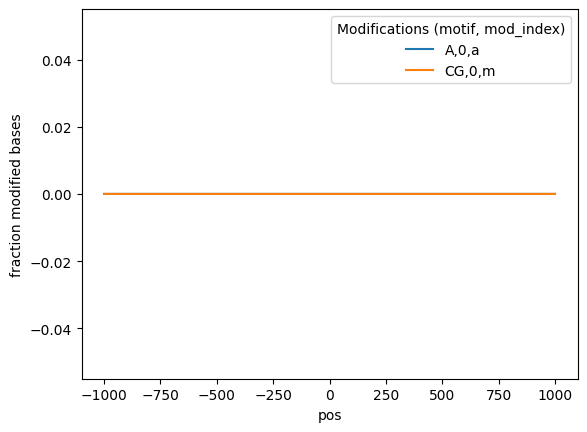

In [54]:
from dimelo import plot_enrichment_profile
plot_enrichment_profile.by_modification(
    mod_file_name=pileup_file_coded,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0,a','CG,0,m'], # We know from above that these mod codes aren't present in our file!
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=50,
)

The `modkit` command below will make the bam file work for the to-spec mod codes m and a. However, you must use this command with caution: `modkit` can and will adjust any mod code to any other mod code; you need to verify yourself that they are actually equivalent and thus that the operation is in fact valid.

In [55]:
run_modkit_checked([
    "adjust-mods",
    "dimelo/test/output/ctcf_demo.updated.bam",
    "dimelo/test/output/ctcf_demo.recoded.bam",
    "--convert",
    "Y",
    "a",
    "--convert",
    "Z",
    "m",
])


modkit required: 0.6.1
modkit active  : 0.6.1
$ modkit adjust-mods dimelo/test/output/ctcf_demo.updated.bam dimelo/test/output/ctcf_demo.recoded.bam --convert Y a --convert Z m


> Converting Y to a
> Converting Z to m
[modkit-core/src/modbam_util/subcommands.rs:774:9] &self.cpg = false
> done, 1024 records processed


In [56]:
ctcf_bam_file_recoded = output_dir / 'ctcf_demo.recoded.bam'
pysam.index(str(ctcf_bam_file_recoded))

''

In [57]:
pileup_file_recoded, pileup_regions = ensure_pileup_output(
    input_file=ctcf_bam_file_recoded,
    output_name='ctcf_demo_pileup_on_target_mod_code_specified_adjusted',
    ref_genome=ref_genome_file,
    output_directory=output_dir,
    regions=[ctcf_target_regions,ctcf_off_target_regions],
    motifs=['A,0,a','CG,0,m'],
    thresh=128,
    window_size=1000,
    # cores=1,
    # cleanup=False,
    # log=True,
    quiet=PARSE_QUIET,
    modkit_executable=MODKIT_BINARY,
)


No specified number of cores requested. 10 available on machine, allocating all.
Detected multiple motif contexts with modkit 0.6.x; running per-motif pileups and merging outputs to avoid mixed-motif empty output behavior.
Modification threshold of 128.0 assumed to be for range 0-255. 128.0/255=0.5019607843137255 will be sent to modkit.


Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

<Axes: xlabel='pos', ylabel='fraction modified bases'>

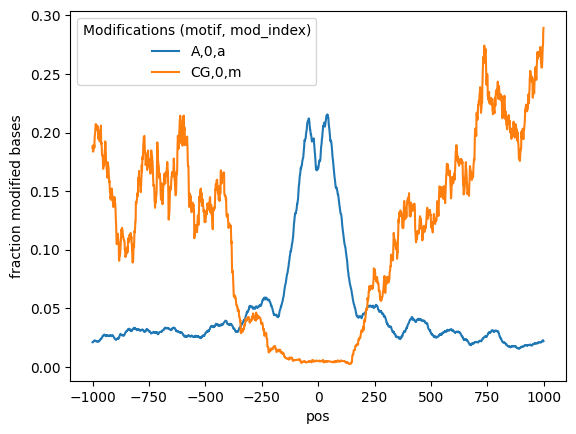

In [58]:
from dimelo import plot_enrichment_profile
plot_enrichment_profile.by_modification(
    mod_file_name=pileup_file_recoded,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0,a','CG,0,m'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=50,
)

# Advanced Use Cases

## Clustering and Classification

This section shows how to work with processed files (`pileup.sorted.bed.gz` and `extract.h5`) to discover structure in your data.

The key idea is to turn each read or region into a feature vector that makes the biological pattern you care about more salient for the current window, motif set, and comparison. A feature is not a result by itself; it is a lens. Good lenses emphasize structure that is plausible for the question (for example center enrichment, flank depletion, periodicity, or motif-specific density) while minimizing nuisance variation such as read depth, missing motif coverage, or arbitrary row order.

- **Read clustering**: build fixed-length windows per read, compute features (PCA, autocorrelation, density, summary stats), and cluster molecules. Supports single motifs or combined multi-motif windows.
- **Read classification**: train a binary classifier on read features to quantify separability between two samples; includes train/test metrics, confusion matrices, and per-read profile plots.
- **Region clustering**: cluster loci on their pileup profiles (single motif or concatenated multi-motif features), and visualize mean profiles plus genome distribution.
- **Region classification**: treat each locus feature vector as a sample for downstream classifiers.

Optional clustering deps: `scikit-learn`, `scipy`, `hdbscan`, `umap-learn`, `pyranges`, `xgboost` (install via `pip install dimelo[clustering]`).
Make sure earlier parsing steps have produced the processed files before running these examples.

### Read analysis and feature-engineering tips

- Use `span_full_window=True` and `orientation_aware=True` when extracting to keep windows comparable across reads.
- For multi-motif windows, set `require_all_motifs=True` to drop reads missing motifs instead of zero-filling.
- `read_window_feature_matrix` currently computes features from the row matrix it receives. For multi-motif windows, that row is a concatenation of motif windows, so PCA, autocorrelation, densities, and summary statistics are computed over the combined representation unless you explicitly build/slice motif-specific matrices.
- Treat feature choices as part of the analysis design. Decide whether the question is about whole-read signal, a centered window, motif-specific signal, cross-motif relationships, or long-range structure before interpreting clusters.
- Drop low-information reads by setting `require_nonzero_valid=True` and `min_valid_fraction` in `read_window_feature_matrix`.
- Inspect feature behavior before trusting a clustering/classifier: check matrix shape, feature names, missing/zero-heavy rows, feature variance, and whether known labels or regions dominate the result.
- Validate rigorously with held-out labels, shuffled labels, sensitivity to window width/motif choice, and visual inspection of representative reads. A clean cluster is only useful if it is stable and biologically interpretable under reasonable parameter changes.
- Inspect cluster/classifier QC: profile plots for clusters, confusion matrices and per-read profile plots for classifiers.
- Check locus homogeneity with `summarize_read_clusters_by_region` (dominant_fraction/entropy) to see if clusters are locus-driven.
- Beware class imbalance in classifiers; look at both accuracy and ROC-AUC, and at confusion matrices to spot overfitting.

### Read Clustering

#### Single motif (merged on-target vs off-target reads)

This example uses the notebook test data directly: extract read windows separately from `ctcf_target_regions`
and `ctcf_off_target_regions`, merge them, and run unsupervised clustering to see whether clusters enrich for one group.


*Motif semantics*: extract output stores one row per motif per read. For multi-motif analyses, use
`build_multimotif_read_windows` and either:
- `motif_profile_mode="single_axis"` to overlay motif profiles on a shared y-axis, or
- `motif_profile_mode="separate_axes"` to keep each motif on its own y-scale.


**Sampling for speed**: Use `cluster.sample_rows` to downsample reads or loci before clustering/classification. Example:

```python
sampled_feat, sampled_labels, idx = cluster.sample_rows(feature_matrix, labels, frac=0.2, stratify=True)
```

Run heavy algorithms (e.g., spectral/DBSCAN/UMAP) on the sample, then apply insights back to the full set.

Reads used: on_target=2173, off_target=4030, total=6203
Feature matrix: 6203 reads x 31 features
K-means input: feature matrix scaled inside read_window_feature_matrix(scale_features=True, family_weighting='equal_family')
Cluster purity vs on/off labels: 0.803
Feature families


,family,n_features
1,density,13
3,summary,7
2,pca,6
0,autocorr,5


Most variable default features


,feature_name,variance,missing_fraction
0,density_minus240,1.0,0.0
1,density_minus150,1.0,0.0
2,density_pm300,1.0,0.0
3,density_minus320,1.0,0.0
4,density_pm500,1.0,0.0
5,pca_2,1.0,0.0
6,global_mod_fraction,1.0,0.0
7,density_minus800,1.0,0.0


Feature scaling preview


,feature_name,scaling_method,family,family_weight,scaled,center,scale,raw_mean,raw_std,scaled_mean,scaled_std
0,pca_0,standard,pca,1.0,True,2.749158e-17,0.258050,-1.806712e-15,0.258050,1.492092e-14,1.0
1,pca_1,standard,pca,1.0,True,1.136891e-16,0.181757,1.674038e-16,0.181757,3.191511e-16,1.0
2,pca_2,standard,pca,1.0,True,7.588821e-17,0.180119,6.489930e-17,0.180119,-1.327372e-16,1.0
3,pca_3,standard,pca,1.0,True,-4.975689e-17,0.177840,-6.906453e-17,0.177840,8.182592e-17,1.0
4,pca_4,standard,pca,1.0,True,1.446172e-16,0.171273,7.534679e-17,0.171273,-6.260419e-16,1.0
5,pca_5,standard,pca,1.0,True,4.388629e-17,0.170655,5.126929e-17,0.170655,-2.866928e-16,1.0
6,autocorr_20,standard,autocorr,1.0,True,6.838372e-03,0.032182,6.838372e-03,0.032182,6.913702e-16,1.0
7,autocorr_75,standard,autocorr,1.0,True,1.028253e-03,0.018921,1.028253e-03,0.018921,-1.265490e-15,1.0


Counts by cluster and region set:


region_set,off_target,on_target
cluster,,
0,3758,952
1,272,1221


Within-cluster fractions:


region_set,off_target,on_target
cluster,,
0,0.798,0.202
1,0.182,0.818


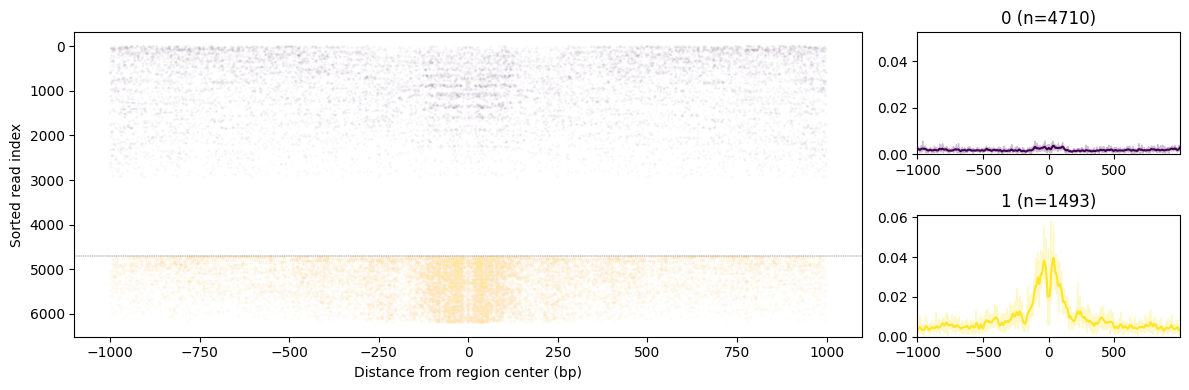

In [16]:
from dimelo import cluster
import importlib
import inspect
import numpy as np
import pandas as pd

# If this notebook kernel already imported dimelo before local edits, reload the module.
cluster = importlib.reload(cluster)
required_kwargs = {"return_feature_table", "scale_features", "return_scale_table"}
observed_kwargs = set(inspect.signature(cluster.read_window_feature_matrix).parameters)
if not required_kwargs.issubset(observed_kwargs):
    raise RuntimeError(
        "This notebook is using an older dimelo.cluster module. "
        f"Imported from: {cluster.__file__}. "
        "Restart the kernel or install this repo in editable mode with `python -m pip install -e .`."
    )

# Fixed window sizes for tutorial reproducibility.
shared_window = 1000
region_window_size = 1000

# Exposed plotting handles for tuning.
plot_point_size = 1.2
plot_point_alpha = 0.015
profile_smoothing = "gaussian"   # None | "gaussian" | "boxcar"
show_unsmoothed_overlay = True

rw_on = cluster.extract_read_windows(
    hdf5_file=extract_file,
    motifs=["A,0"],
    regions=ctcf_target_regions,
    config=cluster.ReadWindowExtractionConfig(
        window_size=shared_window,
        orientation_aware=True,
    ),
    span_full_window=False,
)

rw_off = cluster.extract_read_windows(
    hdf5_file=extract_file,
    motifs=["A,0"],
    regions=ctcf_off_target_regions,
    config=cluster.ReadWindowExtractionConfig(
        window_size=shared_window,
        orientation_aware=True,
    ),
    span_full_window=False,
)

rw_single = cluster.merge_read_window_results(
    [rw_on, rw_off],
    source_labels=["on_target", "off_target"],
    align="error",
)

feat_single_scaled, feat_single_names, feat_single_table, feat_single_scale_table = cluster.read_window_feature_matrix(
    rw_single,
    n_pca=6,
    use_peak_features=False,
    scale_features=True,
    scaling_method="standard",
    family_weighting=None,
    return_feature_table=True,
    return_scale_table=True,
)
feat_single = feat_single_scaled

clust_single = cluster.cluster_read_windows(
    feat_single_scaled,
    method="kmeans",
    n_clusters=2,
    random_state=42,
)

cluster.plot_cluster_profiles(
    data_matrix=rw_single.data_matrix,
    labels=clust_single.labels_size_ordered,
    val_matrix=rw_single.val_matrix,
    metadata=rw_single.metadata,
    window_size=shared_window,
    point_size=plot_point_size,
    point_alpha=plot_point_alpha,
    smoothing=profile_smoothing,
    show_unsmoothed_overlay=show_unsmoothed_overlay,
)

sample_labels_single = np.array([m.get("source_label", "unknown") for m in rw_single.metadata])
feature_summary_single = cluster.summarize_feature_matrix(
    feat_single,
    feat_single_names,
    feature_table=feat_single_table,
    labels=sample_labels_single,
)
cluster_vs_group = pd.crosstab(
    clust_single.labels_size_ordered,
    sample_labels_single,
    rownames=["cluster"],
    colnames=["region_set"],
)
cluster_vs_group_frac = cluster_vs_group.div(cluster_vs_group.sum(axis=1), axis=0)
purity = cluster_vs_group.max(axis=1).sum() / cluster_vs_group.values.sum()

print(f"Reads used: on_target={rw_on.data_matrix.shape[0]}, off_target={rw_off.data_matrix.shape[0]}, total={rw_single.data_matrix.shape[0]}")
print(f"Feature matrix: {feature_summary_single['n_reads']} reads x {feature_summary_single['n_features']} features")
print("K-means input: feature matrix scaled inside read_window_feature_matrix(scale_features=True, family_weighting='equal_family')")
print(f"Cluster purity vs on/off labels: {purity:.3f}")
print("Feature families")
display(feature_summary_single["feature_counts_by_family"])
print("Most variable default features")
display(feature_summary_single["top_variable_features"].head(8))
print("Feature scaling preview")
display(feat_single_scale_table.head(8))
print("Counts by cluster and region set:")
display(cluster_vs_group)
print("Within-cluster fractions:")
display(cluster_vs_group_frac.round(3))

<!-- #### Feature salience knobs to consider

The default feature helper is intentionally compact and remains the default in this notebook for continuity. It computes pooled PCA, autocorrelation, density windows, summary statistics, and optional peak features from the matrix passed into it.

For multi-motif read windows, the matrix is a concatenation of motif-specific windows. A richer `feature_spec` makes that explicit: it can compute per-motif densities, asymmetry, center-versus-edge scores, autocorrelation, FFT/periodicity scores, and cross-motif contrasts while recording which motif and feature family each column came from.

Distance-based methods such as k-means compare Euclidean distances, so raw feature magnitudes matter. In the cells below, `read_window_feature_matrix(scale_features=True, scaling_method="standard", family_weighting="equal_family")` returns the scaled matrix directly. Standard scaling subtracts each feature mean and divides by its standard deviation; equal-family weighting then downweights columns by the square root of the number of columns in their feature family. This keeps high-variance features such as PCA scores or peak counts from overwhelming bounded features, and also keeps large feature families such as density windows from dominating solely by column count. Constant features are mapped to zero and effectively ignored. The standalone `cluster.scale_feature_matrix` helper is available when you want to generate raw features first and compare scaling choices afterward.

Use richer features as analysis design, not automatic truth. Start with a small interpretable feature set, inspect the feature table and scaling table, rank features against known labels only as QC, and then verify clusters by plotting the reads and checking stability under reasonable parameter changes. -->

#### Multiple motif (merged on-target vs off-target reads)

This example plots both motifs with motif-matched colors. You can switch between:
- `motif_profile_mode="single_axis"` (shared y-axis) and
- `motif_profile_mode="separate_axes"` (one y-axis per motif).


Multi-motif reads used: on_target=2173, off_target=4030, total=6203
Default feature matrix: 6203 reads x 31 features
Rich feature matrix: 6203 reads x 108 features
K-means input for cluster labels: raw default feature matrix (legacy tutorial behavior)
Scaled default features are still computed for classifier/QC examples below.
Multi-motif cluster purity vs on/off labels: 0.807
Default feature families


,family,n_features
1,density,13
3,summary,7
2,pca,6
0,autocorr,5


Rich feature families


,family,n_features
3,density,39
6,summary,21
4,fft,15
1,autocorr,12
0,asymmetry,9
2,center_edge,6
5,pca,6


Rich features by motif


...

,feature_name,scaling_method,family,family_weight,scaled,center,scale,raw_mean,raw_std,scaled_mean,scaled_std
0,pooled__pca_0,standard,pca,0.408248,True,8.247473e-17,0.263555,2.953532e-16,0.263555,-1.163807e-15,0.408248
1,pooled__pca_1,standard,pca,0.408248,True,-8.820215e-17,0.188120,-5.014436e-17,0.188120,-1.392041e-16,0.408248
2,pooled__pca_2,standard,pca,0.408248,True,-5.097397e-17,0.184746,-5.361171e-17,0.184746,-6.316709e-17,0.408248
3,pooled__pca_3,standard,pca,0.408248,True,2.245146e-16,0.183379,2.242931e-16,0.183379,-1.639248e-17,0.408248
4,pooled__pca_4,standard,pca,0.408248,True,-5.498316e-17,0.181738,-6.391658e-17,0.181738,-3.460162e-17,0.408248
5,pooled__pca_5,standard,pca,0.408248,True,-1.025207e-16,0.176710,-1.038653e-16,0.176710,1.067625e-17,0.408248
6,"A,0__mean",standard,summary,0.218218,True,3.577463e-03,0.004132,3.577463e-03,0.004132,3.846315e-17,0.218218
7,"A,0__var",standard,summary,0.218218,True,3.547595e-03,0.004076,3.547595e-03,0.004076,-1.556827e-15,0.218218


Rich features most associated with on/off labels (QC, not proof)


,feature_name,effect_score,min_group_mean,max_group_mean,overall_std
0,pooled__pca_0,1.355537,-0.193862,0.359533,0.408248
1,"A,0__density_pm300",1.287086,-0.072199,0.133899,0.160128
2,"A,0__density_pm100",1.281458,-0.071884,0.133314,0.160128
3,"A,0__center_minus_edge",1.215122,-0.173781,0.322290,0.408248
4,"A,0__density_pm500",1.214943,-0.068152,0.126394,0.160128
5,"A,0__density_pm75",1.208016,-0.067764,0.125673,0.160128
6,"A,0__density_pm50",1.084049,-0.060810,0.112777,0.160128
7,"A,0__var",1.042808,-0.079717,0.147842,0.218218
8,"A,0__mean",1.040791,-0.079563,0.147556,0.218218
9,"A,0__mod_fraction",1.022001,-0.078127,0.144892,0.218218


Cluster counts by source


col_0,off_target,on_target
row_0,,
0,3942,1112
1,88,1061


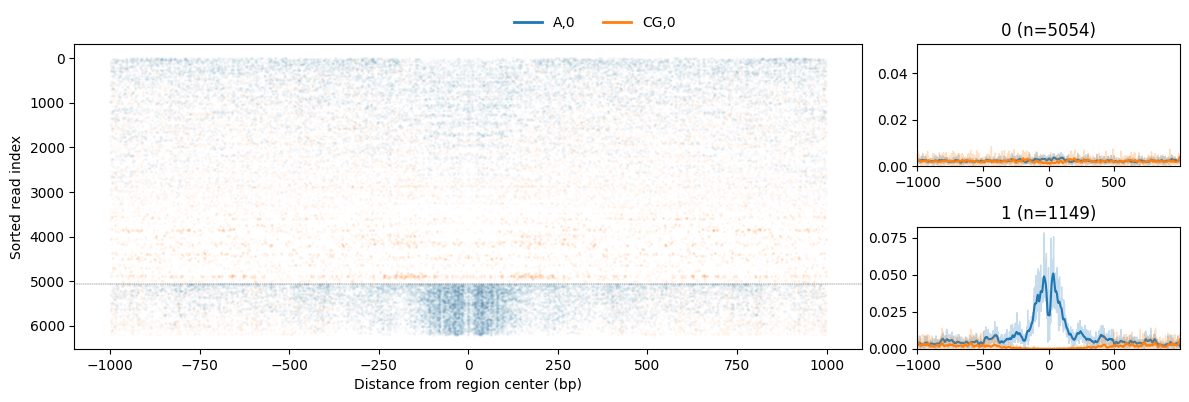

In [18]:
from dimelo import cluster
import numpy as np
import pandas as pd

if "shared_window" not in globals():
    shared_window = 1000

motif_labels = ["A,0", "CG,0"]

rw_on_multi = cluster.build_multimotif_read_windows(
    hdf5_file=extract_file,
    motifs=motif_labels,
    regions=ctcf_target_regions,
    window_size=shared_window,
    orientation_aware=True,
    span_full_window=False,
    require_all_motifs=True,
)

rw_off_multi = cluster.build_multimotif_read_windows(
    hdf5_file=extract_file,
    motifs=motif_labels,
    regions=ctcf_off_target_regions,
    window_size=shared_window,
    orientation_aware=True,
    span_full_window=False,
    require_all_motifs=True,
)

rw_multi = cluster.merge_read_window_results(
    [rw_on_multi, rw_off_multi],
    source_labels=["on_target", "off_target"],
    align="error",
)

# Default pooled feature scheme. Keep the raw legacy matrix for clustering so the
# read-cluster association heatmap matches the original tutorial behavior.
feat_multi, feat_multi_names, feat_multi_table = cluster.read_window_feature_matrix(
    rw_multi,
    n_pca=6,
    use_peak_features=False,
    return_feature_table=True,
)
feat_multi_scaled, feat_multi_scale_table = cluster.scale_feature_matrix(
    feat_multi,
    feat_multi_names,
    feature_table=feat_multi_table,
    method="standard",
    family_weighting="equal_family",
)

# Rich explicit feature scheme used for inspection and feature-salience QC.
rich_feature_spec = {
    "motif_mode": "per_motif",
    "motif_count": len(motif_labels),
    "motif_labels": motif_labels,
    "pooled": True,
    "pca": {"enabled": True, "n_components": 6, "scope": "pooled"},
    "densities": {"enabled": True},
    "asymmetry": {"enabled": True, "spans": [100, 300, 500]},
    "center_edge": {"enabled": True, "center_bp": 100, "edge_bp": 200},
    "autocorr": {"enabled": True, "lags": [20, 75, 150, 250]},
    "fft": {"enabled": True, "periods_bp": [10, 50, 100, 150, 200]},
    "cross_motif": {"enabled": False},
    "peaks": {"enabled": False},
}
feat_multi_rich_scaled, feat_multi_rich_names, feat_multi_rich_table, feat_multi_rich_scale_table = cluster.read_window_feature_matrix(
    rw_multi,
    feature_spec=rich_feature_spec,
    scale_features=True,
    scaling_method="standard",
    family_weighting="equal_family",
    return_feature_table=True,
    return_scale_table=True,
)
feat_multi_rich = feat_multi_rich_scaled

sample_labels_multi = np.array([m.get("source_label", "unknown") for m in rw_multi.metadata])

summary_default = cluster.summarize_feature_matrix(
    feat_multi,
    feat_multi_names,
    feature_table=feat_multi_table,
    labels=sample_labels_multi,
)
summary_rich = cluster.summarize_feature_matrix(
    feat_multi_rich,
    feat_multi_rich_names,
    feature_table=feat_multi_rich_table,
    labels=sample_labels_multi,
)
ranked_rich_features = cluster.rank_read_features_by_group_difference(
    feat_multi_rich,
    feat_multi_rich_names,
    sample_labels_multi,
    top_n=12,
)

clust_multi = cluster.cluster_read_windows(
    feat_multi,
    method="kmeans",
    n_clusters=2,
    random_state=42,
)

cluster.plot_cluster_profiles(
    data_matrix=rw_multi.data_matrix,
    labels=clust_multi.labels_size_ordered,
    val_matrix=rw_multi.val_matrix,
    metadata=rw_multi.metadata,
    window_size=shared_window,
    motif_count=len(motif_labels),
    motif_labels=motif_labels,
    plot_all_motifs=True,
    color_points_by="motif",
    motif_profile_mode="single_axis",
    point_size=plot_point_size,
    point_alpha=plot_point_alpha,
    smoothing=profile_smoothing,
    show_unsmoothed_overlay=show_unsmoothed_overlay,
)

table_multi = pd.crosstab(clust_multi.labels_size_ordered, sample_labels_multi)
purity_multi = table_multi.max(axis=1).sum() / table_multi.values.sum()

print(f"Multi-motif reads used: on_target={rw_on_multi.data_matrix.shape[0]}, off_target={rw_off_multi.data_matrix.shape[0]}, total={rw_multi.data_matrix.shape[0]}")
print(f"Default feature matrix: {summary_default['n_reads']} reads x {summary_default['n_features']} features")
print(f"Rich feature matrix: {summary_rich['n_reads']} reads x {summary_rich['n_features']} features")
print("K-means input for cluster labels: raw default feature matrix (legacy tutorial behavior)")
print("Scaled default features are still computed for classifier/QC examples below.")
print(f"Multi-motif cluster purity vs on/off labels: {purity_multi:.3f}")
print("Default feature families")
display(summary_default["feature_counts_by_family"])
print("Rich feature families")
display(summary_rich["feature_counts_by_family"])
print("Rich features by motif")
display(summary_rich["feature_counts_by_motif"])
print("Default feature scaling preview")
display(feat_multi_scale_table.head(8))
print("Rich feature scaling preview")
display(feat_multi_rich_scale_table.head(8))
print("Rich features most associated with on/off labels (QC, not proof)")
display(ranked_rich_features)
print("Cluster counts by source")
display(table_multi)

### Read Classification

The next cells ask a supervised question: given the engineered read-feature matrix, can a classifier distinguish reads from the on-target and off-target region sets? This is not meant to replace visual inspection or clustering. It is a QC layer that checks whether the feature representation carries separable signal, reports held-out train/test metrics, plots confusion matrices, and then shows the read profiles behind true/false positives and negatives. The examples use the same scaled feature matrices used for k-means so distance- and model-based steps see comparable feature weighting.

#### Single Motif

{'test': {'accuracy': 0.8364222401289283, 'roc_auc': 0.8979606970708195, 'confusion_matrix': [[710, 96], [107, 328]]}, 'train': {'accuracy': 0.8409915356711004, 'roc_auc': 0.891370139660258, 'confusion_matrix': [[2878, 346], [443, 1295]]}}


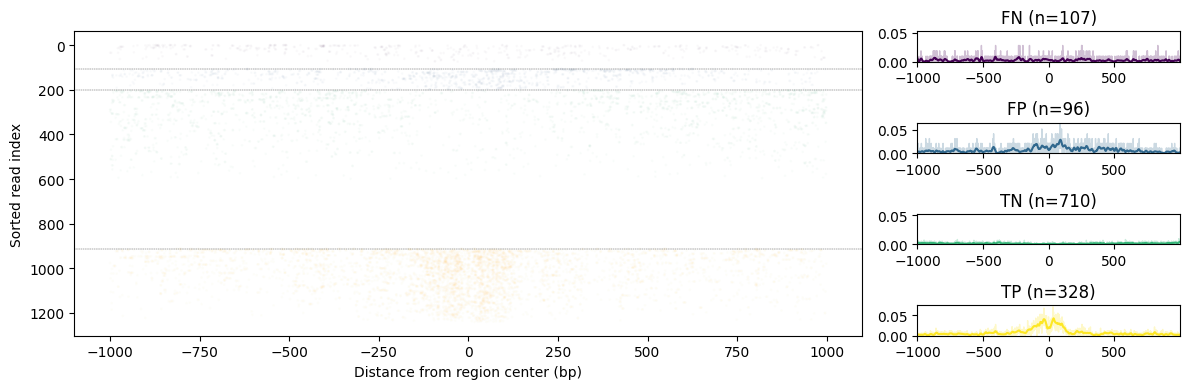

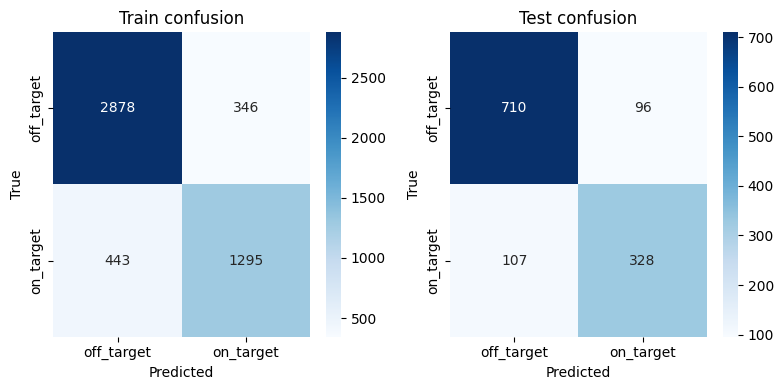

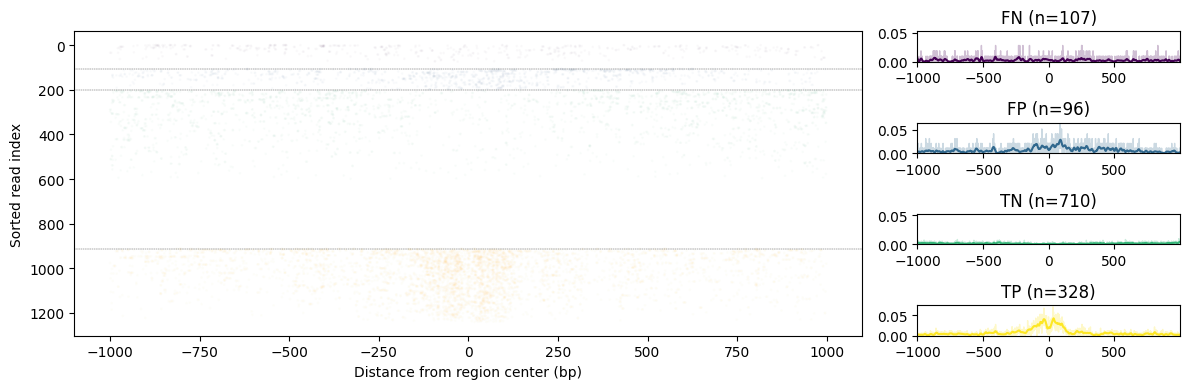

In [19]:
sample_labels_single = np.array([m.get("source_label", "unknown") for m in rw_single.metadata])

clf_single = cluster.classify_read_features_binary(
    feat_single_scaled,
    sample_labels=sample_labels_single,
    classifier="logreg",
    random_state=42,
)
print(clf_single["metrics"])
cluster.plot_confusion_matrices(clf_single["predictions"])

cluster.plot_classification_profiles(
    data_matrix=rw_single.data_matrix,
    predictions=clf_single["predictions"],
    val_matrix=rw_single.val_matrix,
    metadata=rw_single.metadata,
    split="test",
    group_by="confusion",
    window_size=shared_window,
    point_size=plot_point_size,
    point_alpha=plot_point_alpha,
    smoothing=profile_smoothing,
    show_unsmoothed_overlay=show_unsmoothed_overlay,
)

*Tip*: For concatenated motif windows, use `motif_index` in plotting helpers to choose which motif slice to visualize (e.g., 0 for the first motif, 1 for the second).

#### Multiple motifs

{'test': {'accuracy': 0.8436744560838034, 'roc_auc': 0.9122101480277229, 'confusion_matrix': [[709, 97], [97, 338]]}, 'train': {'accuracy': 0.847037484885127, 'roc_auc': 0.9066018454799589, 'confusion_matrix': [[2868, 356], [403, 1335]]}}


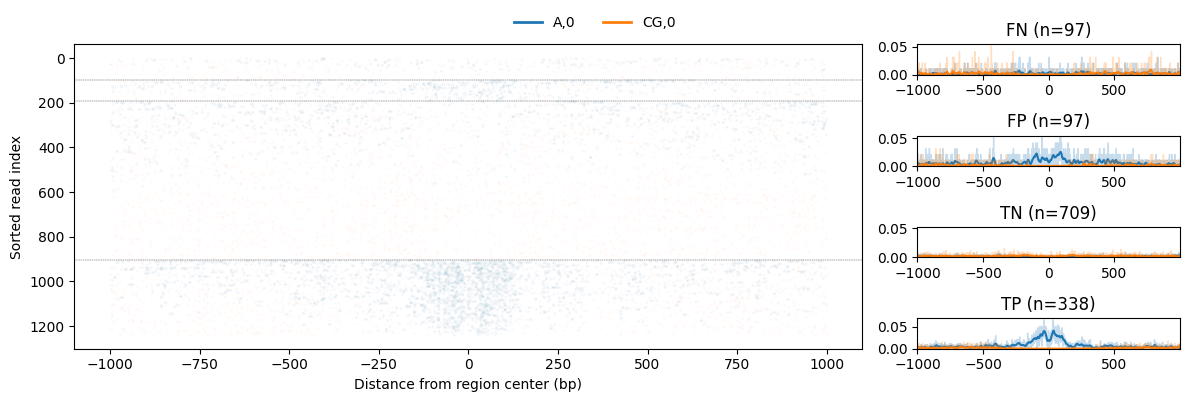

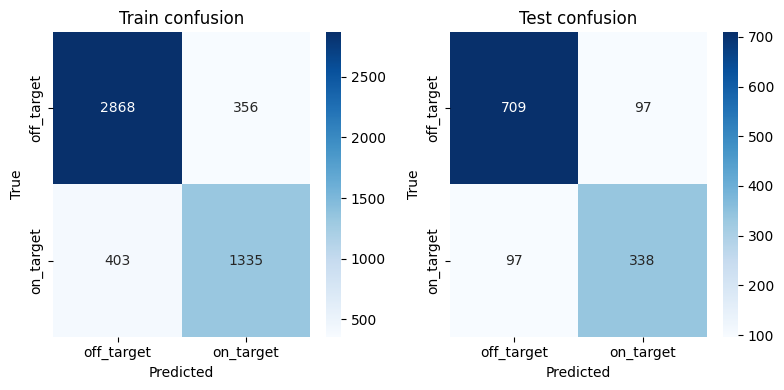

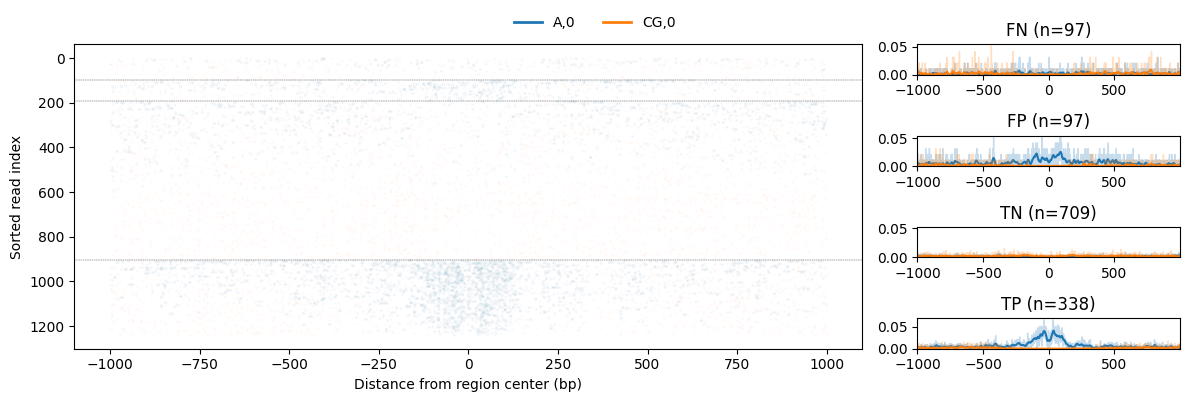

In [20]:
sample_labels_multi = np.array([m.get("source_label", "unknown") for m in rw_multi.metadata])

clf_multi = cluster.classify_read_features_binary(
    feat_multi_scaled,
    sample_labels=sample_labels_multi,
    classifier="logreg",
    random_state=42,
)
print(clf_multi["metrics"])
cluster.plot_confusion_matrices(clf_multi["predictions"])

cluster.plot_classification_profiles(
    data_matrix=rw_multi.data_matrix,
    predictions=clf_multi["predictions"],
    val_matrix=rw_multi.val_matrix,
    metadata=rw_multi.metadata,
    split="test",
    group_by="confusion",
    window_size=shared_window,
    motif_count=len(motif_labels),
    motif_labels=motif_labels,
    plot_all_motifs=True,
    color_points_by="motif",
    motif_profile_mode="single_axis",
    point_size=plot_point_size,
    point_alpha=plot_point_alpha,
    smoothing=profile_smoothing,
    show_unsmoothed_overlay=show_unsmoothed_overlay,
)

### Read-Cluster to Region Association


Read-level clustering stays the primary inference step. Here we aggregate those cluster labels back onto regions, then plot the region-by-cluster association matrix. The cluster labels in this section intentionally use the raw default feature matrix to preserve the original tutorial grouping; the richer/scaled feature matrices above are kept as QC tools for exploring alternative feature salience.

Sorting controls:
- `region_sort_mode` controls row order before the tutorial's final source-bed grouping. It can be one key or a list of keys applied hierarchically. Options are `cluster_fraction`, `input`, `genomic`, and `association_strength`; for example, `["cluster_fraction", "genomic"]` groups by dominant cluster/fraction and then uses genomic coordinates as the next tie-breaker.
- `association_strength_aggregate` only matters when `region_sort_mode="association_strength"`. It defines each region's scalar sorting score from its per-cluster values: `max` uses the strongest cluster association for that region, while `mean` uses the average association across clusters.
- `cluster_sort_mode` controls heatmap column order. Use `natural` for cluster labels in lexical/numeric-looking order, `input` for the order produced by the association table, `total_association` for columns with the largest summed values first, or `max_association` for columns with the strongest single-region association first. You can also pass `cluster_order=[...]` directly to `plot_read_cluster_region_association_heatmap_matplotlib`.
- `row_annotation_columns` can plot any number of categorical region labels as separate bars to the left of the heatmap. Here we show source BED and strand so the row grouping remains visible without crowding the y-axis labels.

In [21]:
from dimelo import plotting, plotting_matplotlib
import importlib
import inspect
import pandas as pd

# Reload plotting modules in case this kernel imported dimelo before local edits.
plotting = importlib.reload(plotting)
plotting_matplotlib = importlib.reload(plotting_matplotlib)
required_plotting_kwargs = {"cluster_sort", "cluster_order"}
observed_plotting_kwargs = set(
    inspect.signature(plotting.prepare_read_cluster_region_association_data).parameters
)
observed_matplotlib_kwargs = set(
    inspect.signature(
        plotting_matplotlib.plot_read_cluster_region_association_heatmap_matplotlib
    ).parameters
)
if (
    not required_plotting_kwargs.issubset(observed_plotting_kwargs)
    or "row_annotation_columns" not in observed_matplotlib_kwargs
):
    raise RuntimeError(
        "This notebook is using an older dimelo.plotting module. "
        f"Imported from: {plotting.__file__}. "
        "Restart the kernel or install this repo in editable mode with `python -m pip install -e .`."
    )

region_sort_mode = ["genomic"]  # string or list, e.g. ["cluster_fraction", "genomic"]
cluster_sort_mode = "natural"  # "input" | "natural" | "total_association" | "max_association"
association_strength_aggregate = "max"  # only used when region_sort="association_strength"
top_regions_per_cluster = 8

association_summary_A = cluster.summarize_read_clusters_by_region(
    metadata=rw_multi.metadata,
    labels=clust_multi.labels_size_ordered,
    include_strand=True,
)
association_payload_A = plotting.prepare_read_cluster_region_association_data(
    association_summary_A,
    value_mode="fraction",
    top_n_regions_per_cluster=top_regions_per_cluster,
    region_sort=region_sort_mode,
    association_strength_aggregate=association_strength_aggregate,
    cluster_sort=cluster_sort_mode,
)

axis_table = cluster.infer_region_source_labels(
    association_payload_A["region_axis_table"],
    rw_multi.metadata,
)
source_priority = {"on_target": 0, "off_target": 1, "unlabeled": 2, "unknown": 3}
axis_table["strand_label"] = axis_table.get("strand", pd.Series("unknown", index=axis_table.index)).fillna("unknown").astype(str)
axis_table["_source_rank"] = axis_table["source_label"].map(source_priority).fillna(99).astype(int)
axis_sorted = axis_table.sort_values(
    ["_source_rank", "chrom", "start", "end"],
    ascending=[True, True, True, True],
).drop(columns=["_source_rank"]).reset_index(drop=True)
region_order = axis_sorted["region_id"].tolist()

matrix_sorted = (
    association_payload_A["matrix_table"].copy()
    .set_index("region_id")
    .loc[region_order]
    .reset_index()
)

association_payload_A["region_axis_table"] = axis_sorted
association_payload_A["matrix_table"] = matrix_sorted
association_payload_A["metadata"] = {
    **association_payload_A.get("metadata", {}),
    "region_sort": "source_bed_then_genomic",
    "cluster_sort": cluster_sort_mode,
}

print("Association payload metadata")
display(pd.DataFrame([association_payload_A["metadata"]]))
print("Region axis preview (sorted)")
display(axis_sorted[["region_id", "chrom", "start", "end", "source_label", "strand_label"]].head())
print("Source label counts")
display(axis_sorted["source_label"].value_counts(dropna=False).rename("n_regions"))

Association payload metadata


,plot_family,value_mode,source_format,region_order,cluster_order,top_n_regions_per_cluster,has_top_regions_table,region_sort,association_strength_aggregate,cluster_sort,chromosome_blocks
0,read_cluster_region_association_heatmap,fraction,legacy_wide,"[chr1:9168068-9168218:+, chr1:9168135-9168218:...","[0, 1]",8,True,source_bed_then_genomic,max,natural,"[{'chrom': 'chr1', 'start_index': 0, 'end_inde..."


Region axis preview (sorted)


,region_id,chrom,start,end,source_label,strand_label
0,chr1:9169918-9170236:+,chr1,9169918,9170236,on_target,+
1,chr1:9169985-9170303:+,chr1,9169985,9170303,on_target,+
2,chr1:9169986-9170302:-,chr1,9169986,9170302,on_target,-
3,chr1:114358436-114358754:+,chr1,114358436,114358754,on_target,+
4,chr1:114358437-114358753:-,chr1,114358437,114358753,on_target,-


Source label counts


source_label
off_target    200
on_target     100
Name: n_regions, dtype: int64

#### Top regions per cluster


In [22]:
association_payload_A["top_regions_table"].head(10)


,region_id,chrom,start,end,strand,cluster,count,fraction,total_reads,value,rank
0,chr12:57871837-57871987:-,chr12,57871837,57871987,-,0,24,1.000000,24,1.000000,1
1,chr12:57871885-57871987:-,chr12,57871885,57871987,-,0,24,1.000000,24,1.000000,2
2,chr12:57875753-57875855:-,chr12,57875753,57875855,-,0,25,1.000000,25,1.000000,3
3,chr12:57875753-57875903:-,chr12,57875753,57875903,-,0,25,1.000000,25,1.000000,4
4,chr14:17377273-17377423:+,chr14,17377273,17377423,+,0,23,1.000000,23,1.000000,5
5,chr14:17377341-17377423:+,chr14,17377341,17377423,+,0,23,1.000000,23,1.000000,6
6,chr14:17381209-17381291:+,chr14,17381209,17381291,+,0,19,1.000000,19,1.000000,7
7,chr15:38664850-38665000:-,chr15,38664850,38665000,-,0,22,1.000000,22,1.000000,8
8,chr9:145236510-145236828:+,chr9,145236510,145236828,+,1,19,0.904762,21,0.904762,1
9,chr9:145236511-145236827:-,chr9,145236511,145236827,-,1,19,0.904762,21,0.904762,2


#### Karyotype view of top associated regions

This adds a genome-level view under **Top regions per cluster**:
- each chromosome is vertical and proportional to true chromosome length,
- coordinate increases downward (0 near the top, chromosome length near the bottom),
- loci are colored by cluster assignment, and
- optional haplotype-aware backbone shading is enabled when maternal/paternal naming is detected.


Wrote karyotype BED to artifacts/notebook/association_regions_by_dominant_cluster.bed
Using chromosome sizes from dimelo/test/output/chm13.draft_v1.0.fasta.fai
chr9: 9 plotted region(s)
chr12: 6 plotted region(s)
chr20: 30 plotted region(s)


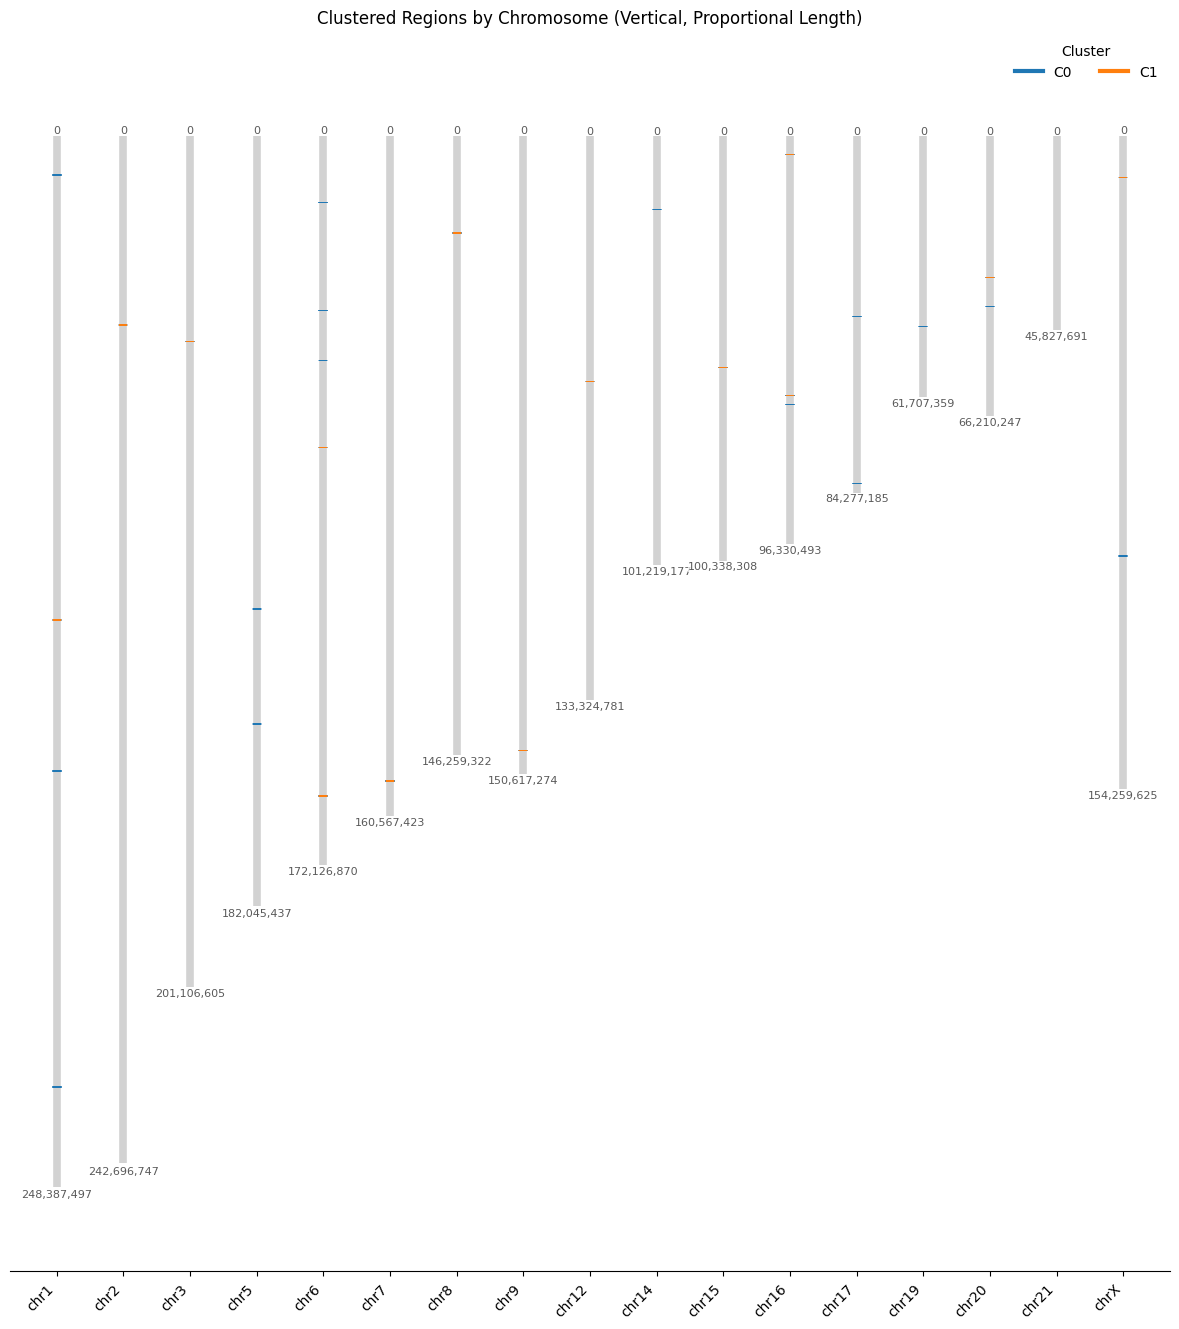

In [23]:
from pathlib import Path
import pandas as pd

from dimelo import cluster

karyotype_chromosome_order = "natural"  # "length_desc" | "length_asc" | "natural" | custom list
karyotype_min_visible_bp = 20_000
karyotype_detect_haplotype_shading = True

matrix_table = association_payload_A["matrix_table"].copy()
axis_table = association_payload_A["region_axis_table"].copy()
cluster_columns = [c for c in matrix_table.columns if c != "region_id"]

if matrix_table.empty or axis_table.empty or not cluster_columns:
    print("No region-association rows available for karyotype plot.")
else:
    dominant_cluster = matrix_table.loc[:, cluster_columns].astype(float).idxmax(axis=1).astype(str)
    dominant_by_region = pd.DataFrame({
        "region_id": matrix_table["region_id"].astype(str),
        "cluster": dominant_cluster,
    })

    karyo_table = axis_table.merge(dominant_by_region, on="region_id", how="inner")
    karyo_table["name"] = karyo_table["cluster"].astype(str)
    karyo_table["score"] = 0
    if "strand" not in karyo_table.columns:
        karyo_table["strand"] = "."
    karyo_table["strand"] = karyo_table["strand"].fillna(".")

    artifacts_dir = Path("artifacts/notebook")
    artifacts_dir.mkdir(parents=True, exist_ok=True)

    karyotype_bed = artifacts_dir / "association_regions_by_dominant_cluster.bed"
    karyo_table.loc[:, ["chrom", "start", "end", "name", "score", "strand"]].to_csv(
        karyotype_bed,
        sep="	",
        header=False,
        index=False,
    )

    chrom_sizes_path = None
    if "ref_genome_file" in globals():
        ref_path = Path(str(ref_genome_file))
        candidate = ref_path.with_suffix(ref_path.suffix + ".fai")
        if candidate.exists():
            chrom_sizes_path = candidate

    if chrom_sizes_path is None:
        inferred_sizes = (
            karyo_table.groupby("chrom", as_index=False)["end"]
            .max()
            .rename(columns={"chrom": "Chromosome", "end": "Length"})
        )
        inferred_sizes["Length"] = (inferred_sizes["Length"] * 1.05).astype(int)
        chrom_sizes_path = artifacts_dir / "inferred.chrom.sizes"
        inferred_sizes.to_csv(chrom_sizes_path, sep="	", header=False, index=False)

    fig = cluster.plot_cluster_karyotype(
        region_bed=karyotype_bed,
        chrom_sizes=chrom_sizes_path,
        chromosome_order=karyotype_chromosome_order,
        invert_position_axis=True,
        detect_haplotype_backbone_shading=karyotype_detect_haplotype_shading,
        min_visible_bp=karyotype_min_visible_bp,
    )

    print(f"Wrote karyotype BED to {karyotype_bed}")
    print(f"Using chromosome sizes from {chrom_sizes_path}")
    for chrom in ["chr9", "chr12", "chr20"]:
        n = int((karyo_table["chrom"].astype(str) == chrom).sum())
        print(f"{chrom}: {n} plotted region(s)")


#### Association heatmap


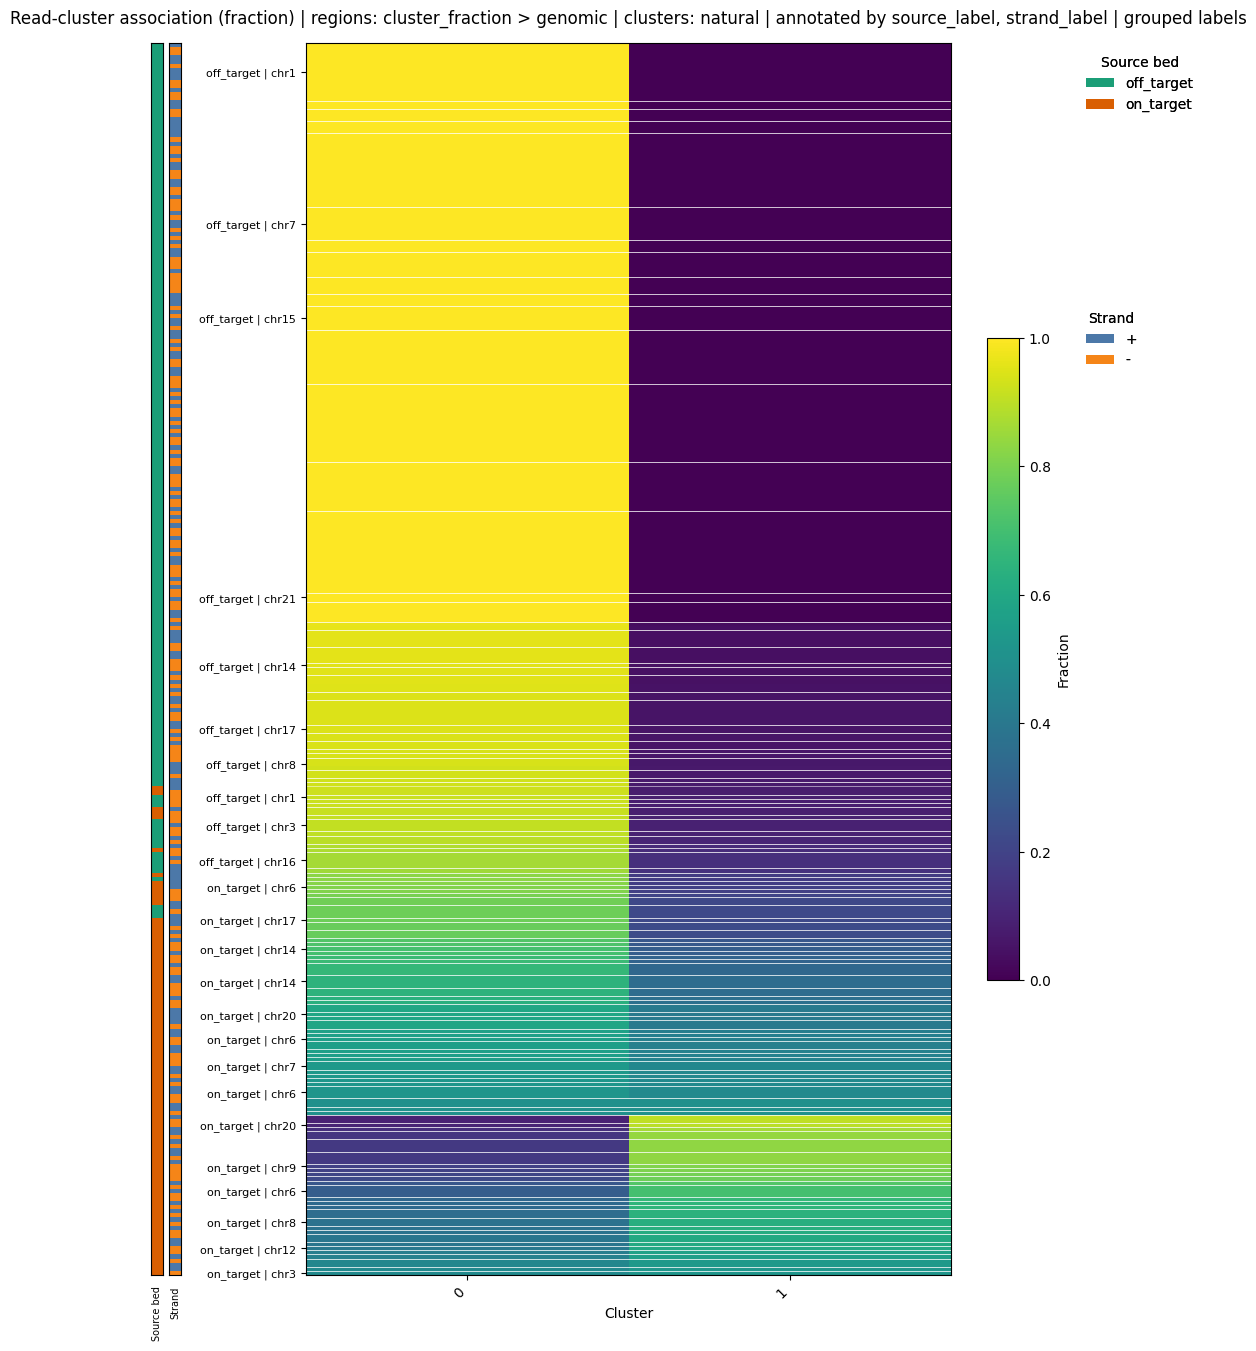

In [24]:
import matplotlib.pyplot as plt

fig, ax = plotting_matplotlib.plot_read_cluster_region_association_heatmap_matplotlib(
    association_payload_A,
    region_label_mode="chromosome",
    max_region_labels=24,
    row_annotation_columns=["source_label", "strand_label"],
    row_annotation_titles={
        "source_label": "Source bed",
        "strand_label": "Strand",
    },
    row_annotation_palettes={
        "source_label": {
            "on_target": "#D95F02",
            "off_target": "#1B9E77",
            "unlabeled": "#7570B3",
            "unknown": "#999999",
        },
        "strand_label": {"+": "#4C78A8", "-": "#F58518", ".": "#999999", "unknown": "#999999"},
    },
    cluster_sort=cluster_sort_mode,
    region_sort=['cluster_fraction','genomic'],
    group_region_labels=True,
    group_label_columns=["source_label", "chrom"]
)
plt.show()


# Two-site raster demo
## What it does:
 - selects two sites from the same read at a strict fixed offset and displays a window around each site,
 - keeps row sorting matched across motifs,
 - shows either read-coordinate spacing or local window-centered coordinates,
 - supports uniform, random, and heatmap bin-mean downsampling.

The default two-site view keeps Site 1 centered at 0 and Site 2 at the requested offset in read coordinates. Use `coordinate_mode="local_window"` when you want each panel centered on its own selected site.


Two-site fixed-offset raster stats: {'pairs': 56, 'rows_are': 'reads', 'unique_reads': 56, 'site_sets': 56, 'rows_before_downsample': 56, 'rows_after_downsample': 56, 'downsampled': False, 'downsample_method': 'none', 'coordinate_mode': 'relative_to_primary', 'selection_mode': 'fixed_offsets', 'window_offsets_bp': [0.0, 2000.0], 'window_widths_bp': [2000, 2000], 'ml_score_thresholds': None, 'observed_offsets_bp': [{'n': 56, 'min': 0.0, 'median': 0.0, 'max': 0.0, 'unique': 1}, {'n': 56, 'min': 2000.0, 'median': 2000.0, 'max': 2000.0, 'unique': 1}], 'site_selection': {'mode': 'fixed_offsets', 'n_windows': 2, 'min_distance_bp': 2000, 'max_distance_bp': None, 'selection_multiplicity': 'one_per_read', 'choose': 'first', 'selection_seed': None, 'anchor': {'mode': 'first'}, 'strand_relation': 'any', 'orientation': 'genomic', 'excluded_sites': 0}}
Vertical-axis scatter stats: {'pairs': 56, 'rows_are': 'reads', 'unique_reads': 56, 'site_sets': 56, 'rows_before_downsample': 56, 'rows_after_downs

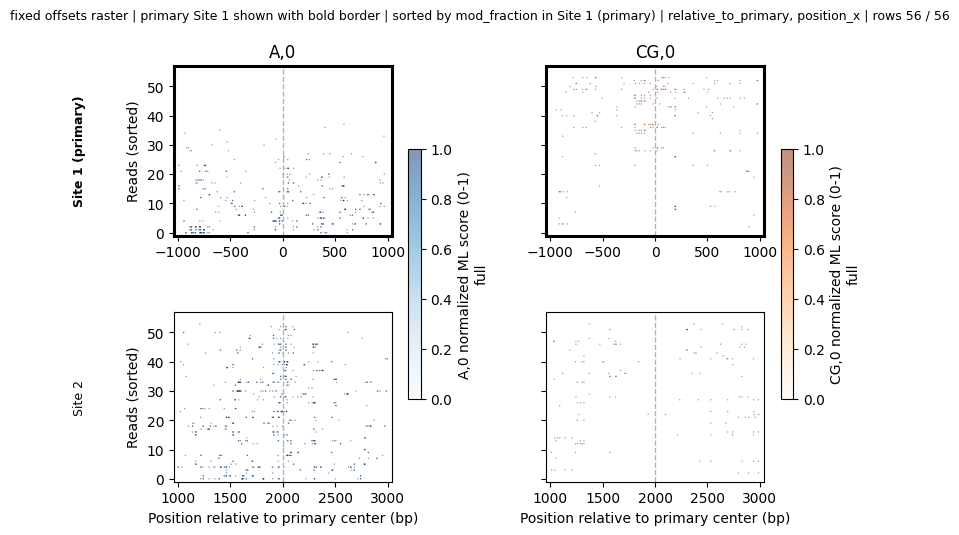

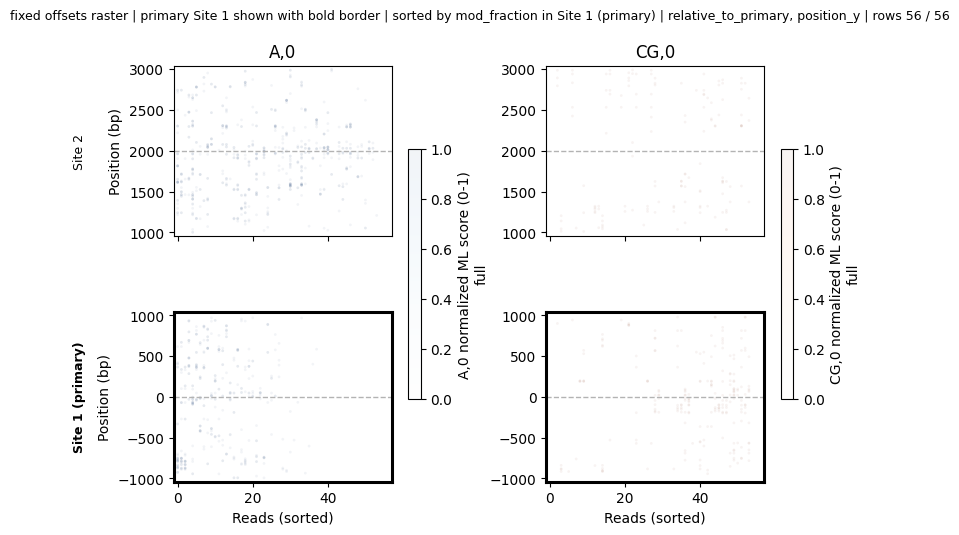

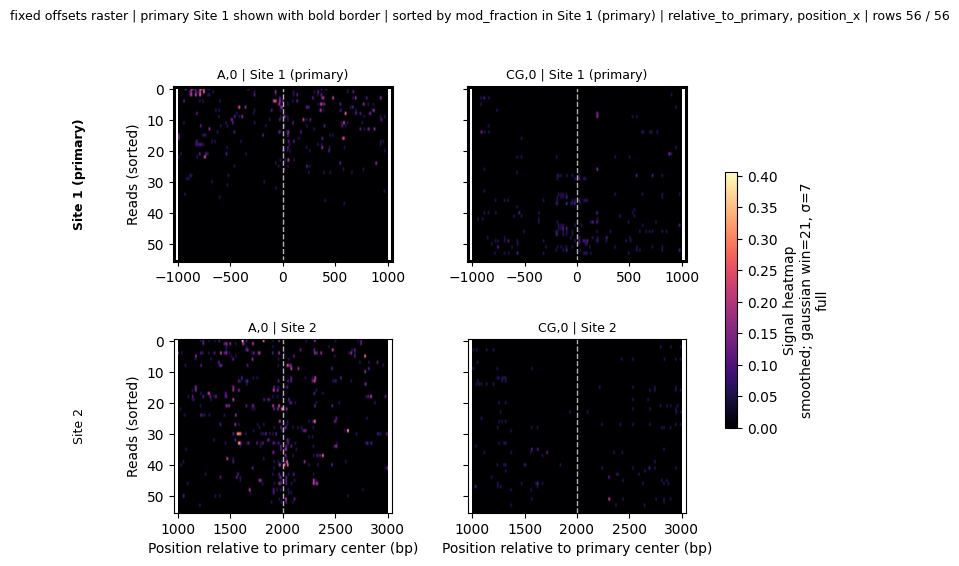

In [ ]:
raster_render_mode = "scatter"  # "scatter" | "heatmap"
raster_render_values = "raw"    # "auto" | "raw" | "smoothed"
raster_axis_orientation = "position_x"  # "position_x" | "position_y"
raster_coordinate_mode = "relative_to_primary"  # "relative_to_primary" | "local_window"
raster_max_rows = 500  # cap displayed reads; set None to show all
raster_downsample_method = "auto"  # "auto" | "uniform" | "random" | "bin_mean"
raster_downsample_seed = 42  # used when downsample_method="random"
raster_plot_all_motifs = True
raster_second_site_offset_bp = 2000
raster_window_width_bp = 2000

# Optional motif-specific ML thresholds for thresholded motif-color rendering.
# Set to None to use continuous ML-score coloring (default behavior).
raster_ml_thresholds = None  # example: [0.70, 0.80]
raster_motif_colors = ["#1f77b4", "#ff7f0e"]

# Sorting controls. Site 1 is the primary site for the two-site wrapper.
raster_sort_by = "mod_fraction"  # "mod_fraction" | "cluster" | "window_center" | "read_name" | "region_start" | "read_length" | "none"
raster_sort_window_index = 0
raster_sort_descending = True

show_vertical_axis_variant = True
show_heatmap_variant = True


fig, stats = cluster.plot_two_site_read_raster(
    read_windows=rw_multi,
    second_site_offset_bp=raster_second_site_offset_bp,
    window_width_bp=raster_window_width_bp,
    motif_index=0,
    motif_count=2,
    plot_all_motifs=raster_plot_all_motifs,
    motif_labels=["A,0", "CG,0"],
    motif_colors=raster_motif_colors,
    ml_score_thresholds=raster_ml_thresholds,
    smoothing=None,
    render_mode=raster_render_mode,
    render_values=raster_render_values,
    scatter_color_values="ml_score",
    axis_orientation=raster_axis_orientation,
    coordinate_mode=raster_coordinate_mode,
    sort_by=raster_sort_by,
    sort_window_index=raster_sort_window_index,
    sort_descending=raster_sort_descending,
    scatter_size=1,
    scatter_alpha=0.5,
    max_rows=raster_max_rows,
    downsample_method=raster_downsample_method,
    downsample_seed=raster_downsample_seed,
)
print("Two-site fixed-offset raster stats:", cluster.raster_stats_brief(stats))

if show_vertical_axis_variant:
    fig_vert, stats_vert = cluster.plot_two_site_read_raster(
        read_windows=rw_multi,
        second_site_offset_bp=raster_second_site_offset_bp,
        window_width_bp=raster_window_width_bp,
        motif_index=0,
        motif_count=2,
        plot_all_motifs=raster_plot_all_motifs,
        motif_labels=["A,0", "CG,0"],
        motif_colors=raster_motif_colors,
        ml_score_thresholds=raster_ml_thresholds,
        smoothing=None,
        render_mode="scatter",
        render_values="raw",
        scatter_color_values="ml_score",
        axis_orientation="position_y",
        coordinate_mode=raster_coordinate_mode,
        sort_by=raster_sort_by,
        sort_window_index=raster_sort_window_index,
        sort_descending=raster_sort_descending,
        scatter_size=4,
        scatter_alpha=0.05,
        max_rows=raster_max_rows,
        downsample_method=raster_downsample_method,
        downsample_seed=raster_downsample_seed,
    )
    print("Vertical-axis scatter stats:", cluster.raster_stats_brief(stats_vert))

if show_heatmap_variant:
    fig_hm, stats_hm = cluster.plot_two_site_read_raster(
        read_windows=rw_multi,
        second_site_offset_bp=raster_second_site_offset_bp,
        window_width_bp=raster_window_width_bp,
        motif_index=0,
        motif_count=2,
        plot_all_motifs=raster_plot_all_motifs,
        motif_labels=["A,0", "CG,0"],
        smoothing="gaussian",
        render_mode="heatmap",
        render_values="smoothed",
        smooth_sigma_bp=7,
        smooth_win=21,
        axis_orientation="position_x",
        coordinate_mode=raster_coordinate_mode,
        sort_by=raster_sort_by,
        sort_window_index=raster_sort_window_index,
        sort_descending=raster_sort_descending,
        max_rows=raster_max_rows,
        downsample_method="bin_mean",
        downsample_seed=raster_downsample_seed,
    )
    print("Heatmap stats:", cluster.raster_stats_brief(stats_hm))


### Co-occurring-region raster demo (two sites)

This uses the full `plot_multisite_read_raster` selector. It finds reads with two regions separated by at least the requested distance and plots each selected site in its own local coordinate system. The same selector supports arbitrary numbers of sites by increasing `n_windows`.


Co-occurring-region raster stats: {'pairs': 500, 'rows_are': 'reads', 'unique_reads': 664, 'site_sets': 664, 'rows_before_downsample': 664, 'rows_after_downsample': 500, 'downsampled': True, 'downsample_method': 'random', 'coordinate_mode': 'local_window', 'selection_mode': 'cooccurring', 'window_offsets_bp': None, 'window_widths_bp': [2000, 2000], 'ml_score_thresholds': {'A,0': 0.65, 'CG,0': 0.5}, 'observed_offsets_bp': [{'n': 664, 'min': 0.0, 'median': 0.0, 'max': 0.0, 'unique': 1}, {'n': 664, 'min': 2000.0, 'median': 3868.0, 'max': 3898.0, 'unique': 24}], 'site_selection': {'mode': 'cooccurring', 'n_windows': 2, 'min_distance_bp': 2000, 'max_distance_bp': None, 'selection_multiplicity': 'one_per_read', 'choose': 'first', 'selection_seed': 42, 'anchor': {'mode': 'first'}, 'strand_relation': 'any', 'orientation': 'genomic', 'excluded_sites': 0}}


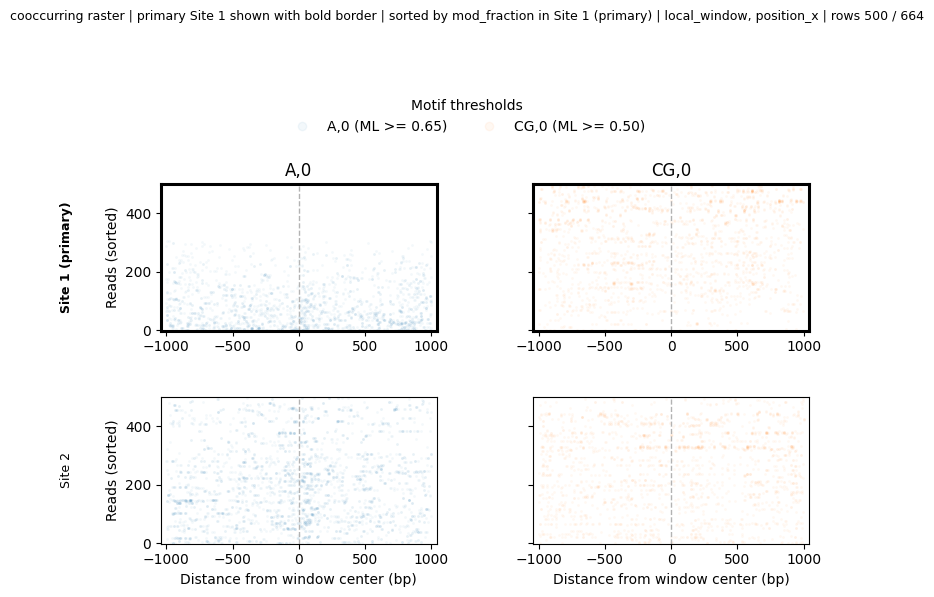

In [ ]:
cooccurring_ml_thresholds = [0.65, 0.50]
cooccurring_motif_colors = ["#1f77b4", "#ff7f0e"]

cooccurring_selection = {
    "mode": "cooccurring",
    "n_windows": 2,
    "min_distance_bp": "window_width",  # defaults to the displayed window width
    "max_distance_bp": None,
    "selection_multiplicity": "one_per_read",
    "choose": "first",  # "first" | "random" | "longest_span" | "shortest_span"
    "selection_seed": raster_downsample_seed,
    "anchor": {"mode": "first"},  # "first" | "random" | {"mode": "index", "index": 0}
    "strand_relation": "any",  # "any" | "same" | "opposite"
    "exclude": None,  # e.g. {"regions": "chr1:1000-2000", "row_indices": [0, 1]}
    "orientation": "genomic",  # "genomic" | "anchor_strand"
}
# Other useful choices:
# cooccurring_selection["choose"] = "longest_span"
# cooccurring_selection.update({"choose": "random", "selection_seed": 42})
# cooccurring_selection["exclude"] = {"regions": ctcf_off_target_regions}

fig_co, stats_co = cluster.plot_multisite_read_raster(
    read_windows=rw_multi,
    site_selection=cooccurring_selection,
    coordinate_mode="local_window",
    motif_index=0,
    motif_count=2,
    plot_all_motifs=True,
    motif_labels=["A,0", "CG,0"],
    motif_colors=cooccurring_motif_colors,
    ml_score_thresholds=cooccurring_ml_thresholds,
    window_widths_bp=[raster_window_width_bp, raster_window_width_bp],
    render_mode="scatter",
    render_values="raw",
    scatter_color_values="ml_score",
    axis_orientation="position_x",
    smoothing=None,
    sort_by="mod_fraction",
    sort_window_index=0,
    sort_descending=True,
    scatter_size=4,
    scatter_alpha=0.05,
    max_rows=raster_max_rows,
    downsample_method="random",
    downsample_seed=raster_downsample_seed,
)
print("Co-occurring-region raster stats:", cluster.raster_stats_brief(stats_co))
